This script clusters the different features and representations exported from .feature_extraction.ipynb.

At the beginning of every run, the dataset is bootstrapped to retrieve different class subset sizes.

1) Nearest neighbour graphs of all representations are created based on euclidian distance
2) Embeddings are created using **UMAP** and **Hopkins** statistic computed for each embeddings- and original feature space
3) The following three clustering algorithms are applied:
    - **kMeans**
    - **HDBSCAN**
    - **Leiden**
4) All resulting clusterings are evaluated with
    - **silhouette score**
    - **V-measure**
    - **Adjusted Rand score**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
import random
from tqdm.auto import tqdm

from sklearn.preprocessing import LabelEncoder
import umap
from umap.umap_ import nearest_neighbors
from sklearn.preprocessing import StandardScaler

from sklearn.metrics.cluster import v_measure_score, completeness_score, homogeneity_score
from sklearn.metrics import adjusted_rand_score, silhouette_score

from utils import plotting, clustering, stats
from sklearn.manifold import trustworthiness

/Users/lenagies/anaconda3/envs/goose_vocalizations/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# For plotting
sns.set_theme(style="ticks", font_scale=1.7)
CALL_TYPE_COLORS = {'alarm': (0.2823529411764706, 0.47058823529411764, 0.8156862745098039), 
                    'contact': (0.9333333333333333, 0.5215686274509804, 0.2901960784313726), 
                    'departure': (0.41568627450980394, 0.8, 0.39215686274509803), 
                    'distance': (0.8392156862745098, 0.37254901960784315, 0.37254901960784315), 
                    'recruitment': (0.5843137254901961, 0.4235294117647059, 0.7058823529411765), 
                    'triumph': (0.5490196078431373, 0.3803921568627451, 0.23529411764705882)}
DOT_SIZE = 10
ALPHA = .5

In [3]:
columns = [
    'Representation', 
    'Algorithm', 
    'Distance metric', 
    'Subset size', 
    'Cluster labels', 
    'V-measure', 
    'Adj. RS', 
    'Hopkins', 
    'Silhouette Score', 
    'Modularity',
    'Homogeneity',
    'Completeness'
    ]

results_df = pd.DataFrame(columns=columns)

In [4]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [5]:
# List of titles for plots of PAFs
feature_titles_list = [
    "Duration [s]",
    "Temporal 1st Quartile [s]", 
    "Temporal Median [s]", 
    "Temporal 3rd Quartile [s]", 
    "Temporal Standard Deviation [s]", 
    "Temporal Skewness", 
    "Temporal Kurtosis", 
    "Temporal Entropy", 
    "Mean Frequency [kHz]",
    "Mean Peak Frequency [kHz]",
    "Spectral Sandard Deviation [kHz]",
    "Spectral Flatness", 
    "Frequency 1st Quartile [kHz]",
    "Frequency Median [kHz]", 
    "Frequency 3rd Quartile [kHz]", 
    "Mean Dominant Frequency [kHz]", 
    "Min Dominant Frequency [kHz]",
    "Max Dominant Frequency [kHz]", 
    "Dominant Frequency Range [kHz]", 
    "Dominant Frequency Modulation [kHz]", 
    "Spectral Entropy", 
    "Harmonics-to-Noise Ratio [dB]",
    "Spectrographic Entropy"
    ]

# List of column names of PAFs
feature_columns_list = [
    "duration",
    "t_q1", 
    "t_median", 
    "t_q3", 
    "std_t", 
    "skew_t", 
    "kurt_t", 
    "t_entropy", 
    "mean_f",
    "mean_peak_f", 
    "std_f",
    "flatness_s", 
    "f_q1",
    "f_median", 
    "f_q3", 
    "mean_dom", 
    "min_dom",
    "max_dom", 
    "range_dom", 
    "mod_dom", 
    "pse", 
    "hnr",
    "spectrographic_entropy"
    ]

In [6]:
len(feature_columns_list)

23

# Import the dataset

In [7]:
calls_df = pd.read_csv('pickles_and_csvs/features_and_spectrograms.csv')
calls_df['log_padded_spectrogram'] = calls_df['log_padded_spectrogram'].apply(lambda x: np.array(json.loads(x)))
calls_df['log_padded_log_freq_spectrogram'] = calls_df['log_padded_log_freq_spectrogram'].apply(lambda x: np.array(json.loads(x)))
calls_df['log_padded_lfccs'] = calls_df['log_padded_lfccs'].apply(lambda x: np.asarray(json.loads(x)))
calls_df['log_padded_mfccs'] = calls_df['log_padded_mfccs'].apply(lambda x: np.asarray(json.loads(x)))

In [8]:
# import latent representations from VAE and merge with calls df
representations_df = pd.read_csv("pickles_and_csvs/latent_representations_CVAE_adam.csv")
representations_df["latent_representation"] = representations_df["latent_representation"].apply(lambda x: np.asarray(json.loads(x)))
calls_df = pd.merge(calls_df, representations_df, on="clip_ID")
calls_df = calls_df.drop(columns=["call_type_y"])
calls_df = calls_df.rename(columns={"call_type_x": "call_type"})

In [9]:
print(len(calls_df[calls_df.isna().any(axis=1)]))
calls_df = calls_df.dropna()
calls_df.info()

0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 40 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   track_ID                         7043 non-null   object 
 1   clip_ID                          7043 non-null   object 
 2   goose_ID                         7043 non-null   object 
 3   call_type                        7043 non-null   object 
 4   waveform                         7043 non-null   object 
 5   sr                               7043 non-null   int64  
 6   filepath                         7043 non-null   object 
 7   log_scaled_spectrogram           7043 non-null   object 
 8   lfccs                            7043 non-null   object 
 9   mfccs                            7043 non-null   object 
 10  peak                             7043 non-null   float64
 11  duration                         7043 non-null   float64
 12  log_padded_spectro

/var/folders/kl/qgqbw3bd42bf_tybhvnz9vxh0000gn/T/ipykernel_2033/1510808998.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  hist = sns.histplot(


[]

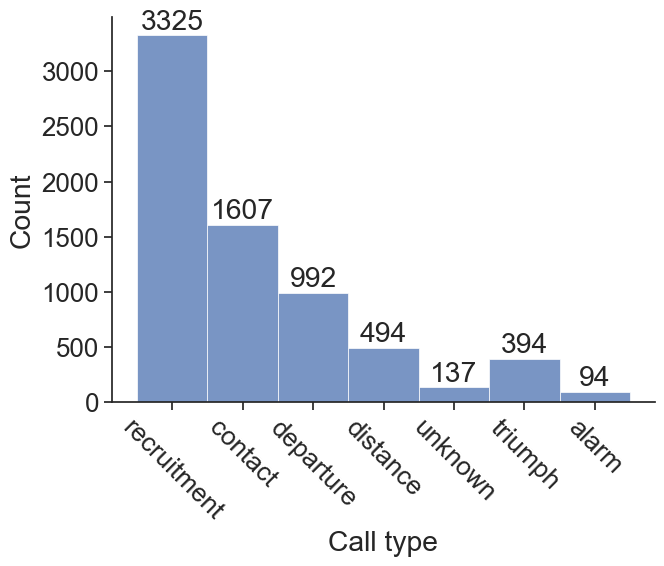

In [10]:
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)

hist = sns.histplot(
    calls_df,
    x="call_type",
    multiple="stack",
    palette="viridis",
    edgecolor="1",
    linewidth=.5,
)

plt.xticks(rotation=-45)
ax.set_xlabel("Call type")

# Add counts
for p in hist.patches:
    height = p.get_height()
    x = p.get_x() + p.get_width() / 2
    ax.annotate(f'{int(height)}', (x, height), ha='center', va='bottom')
    
plt.plot()

In [11]:
# Group discard unknown calls
calls_df = calls_df[calls_df['call_type']!='unknown']

## Draw random subset size and run pipeline

In [12]:
def create_representations_subdf_and_scale(full_df, column_name, column_names=["call_type", "track_ID", "goose_ID"]):
    column_names_new_df = column_names.copy()
    subset_list = []
    for idx, row in full_df.iterrows():
        subset_list.append([row["call_type"], row["track_ID"], row["goose_ID"], *row[column_name].flatten()])

    for i in range(len(full_df.iloc[0][column_name].flatten())):
        column_names_new_df.append(i)

    subset_df = pd.DataFrame(subset_list, columns=column_names_new_df, index=None)
    subset_df.head()

    subset_scaled = StandardScaler().fit_transform(subset_df.drop(columns=column_names))

    return subset_scaled, subset_df

In [13]:
def resample_subset(subset_size, df):
    subsample_sizes = {
        'recruitment': subset_size,
        'contact': subset_size,
        'departure': subset_size,
        'distance': subset_size,
        'triumph': subset_size,
        'alarm': subset_size
    }

    def subsample_group(group):
        call_type = group.name  
        target_size = subsample_sizes.get(call_type, 0)  # Default to 0 if missing

        if len(group) > target_size:
            return group.sample(n=target_size, random_state=RANDOM_SEED)
        return group  # Return full group if it's already smaller than the target size
    
    return df.groupby('call_type', group_keys=False)[df.columns.tolist()].apply(subsample_group)

In [14]:
NEIGHBORS_RATIO = .2
DISTANCE_METRIC = "euclidean"

In [ ]:
def plot_all(subset_df, embeddings_paf, embeddings_lfcc, embeddings_spec, embeddings_vae):
    plotting.plot_embeddings_with_colorcoded_label(subset_df, embeddings_paf, "call_type", "UMAP embeddings of PAF", "Call Type")
    plotting.plot_embeddings_with_colorcoded_label(subset_df, embeddings_lfcc, "call_type", "UMAP embeddings of LFCC", "Call Type")
    plotting.plot_embeddings_with_colorcoded_label(subset_df, embeddings_spec, "call_type", "UMAP embeddings of spectrograms", "Call Type")
    plotting.plot_embeddings_with_colorcoded_label(subset_df, embeddings_vae, "call_type", "UMAP embeddings of VAE representations", "Call Type")

    plotting.plot_embeddings_with_colorcoded_label(subset_df, embeddings_paf, "goose_ID", "UMAP embeddings of PAF - Goose ID", show_legend=False)
    plotting.plot_embeddings_with_colorcoded_label(subset_df, embeddings_lfcc, "goose_ID", "UMAP embeddings of LFCC - Goose ID", show_legend=False)
    plotting.plot_embeddings_with_colorcoded_label(subset_df, embeddings_spec, "goose_ID", "UMAP embeddings of spectrograms - Goose ID", show_legend=False)
    plotting.plot_embeddings_with_colorcoded_label(subset_df, embeddings_vae, "goose_ID", "UMAP embeddings of VAE representations - Goose ID", show_legend=False)

    plotting.plot_embeddings_with_colorcoded_label(subset_df, embeddings_paf, "track_ID", "UMAP embeddings of PAF - Track ID", show_legend=False)
    plotting.plot_embeddings_with_colorcoded_label(subset_df, embeddings_lfcc, "track_ID", "UMAP embeddings of LFCC - Track ID", show_legend=False)
    plotting.plot_embeddings_with_colorcoded_label(subset_df, embeddings_spec, "track_ID", "UMAP embeddings of spectrograms - Track ID", show_legend=False)
    plotting.plot_embeddings_with_colorcoded_label(subset_df, embeddings_vae, "track_ID", "UMAP embeddings of VAE representations - Track ID", show_legend=False)

In [16]:
from sklearn.metrics.pairwise import pairwise_distances
import itertools
def continuity(X, X_embedded, *, n_neighbors=5, input_metric='precomputed', output_metric = 'euclidean'):
    """
    Taken rom Martin et al. 2023: https://gitlab.com/kimartin/cluster_rook_vocs/-/blob/main/utilities/clusterability.py?ref_type=heads
    """
    if not isinstance(X_embedded, list):
        X_embedded = [X_embedded]
    if not isinstance(n_neighbors, list):
        n_neighbors = [n_neighbors]

    if 1 != len(n_neighbors) and len(n_neighbors) != len(X_embedded):
        raise ValueError(f'X_embbedded is a list of length {len(X_embedded)} but n_neighbors is a list of '
                         f'length {len(n_neighbors)}, please provide two lists of the same length (or a scalar value for n_neighbors')

    n_samples = len(X)

    if input_metric != 'precomputed':
        X = pairwise_distances(X, metric=input_metric)

    # we set the diagonal to np.inf to exclude the points themselves from
    # their own neighborhood
    np.fill_diagonal(X, np.inf)
    ind_X = np.argsort(X, axis=1)

    # We build an inverted index of neighbors in the input space: For sample i,
    # we define `inverted_index[i]` as the inverted index of sorted distances:
    # inverted_index[i][ind_X[i]] = np.arange(1, n_sample + 1)
    # initiate to np.int64 instead of plain int to limit integer overflow
    inverted_index = np.zeros((n_samples, n_samples), dtype=np.int64)
    ordered_indices = np.arange(n_samples + 1)
    inverted_index[ordered_indices[:-1, np.newaxis], ind_X] = ordered_indices[1:]

    def _compute_continuity(embedded_X, k):
        if output_metric != 'precomputed':
            embedded_X = pairwise_distances(embedded_X, metric=output_metric)

        np.fill_diagonal(embedded_X, np.inf)
        ind_X_embedded = np.argsort(embedded_X, axis=1)

        inverted_index = np.zeros((n_samples, n_samples), dtype=np.int64)
        ordered_indices = np.arange(n_samples + 1)
        inverted_index[ordered_indices[:-1, np.newaxis], ind_X_embedded] = ordered_indices[1:]

        ranks = inverted_index[ordered_indices[:-1, np.newaxis], ind_X[:, :k]] - k
        t = np.sum(ranks[ranks > 0])
        K = 2. / (n_samples * k * (2. * n_samples - 3. * k - 1.))
        c = 1. - t * K
        return c

    cont = np.array([_compute_continuity(x, n) for x, n in zip(X_embedded, itertools.cycle(n_neighbors))])

    return np.mean(cont)


In [ ]:
# run for different subset sizes
algorithms = [
            ("k-means-preset", 0),     
            ("kMeans", 1), 
            ("HDBSCAN", 2),
            ("Leiden", 3), 
            # ("Leiden-preset", 4),
        ]
rows = []

for subset_size in [50, 100, 200, 500, 4000]:
    n_classes = 6 if 200 <= subset_size <= 4000 else 5
    subset_df = calls_df.copy() if subset_size <= 100 or 4000 else calls_df[calls_df["call_type"] != "alarm"].copy()
    # resample dataset
    for i in tqdm(range(50) if subset_size<4000 else range(5)):
        RANDOM_SEED+=10
        n_neighbors = int(subset_size * NEIGHBORS_RATIO) if subset_size < 4000 else 100
        subset_df = resample_subset(subset_size, subset_df)

        # Encode call type
        le = LabelEncoder()
        le.fit(subset_df["call_type"])
        subset_df["encoded_call_type"] = le.transform(subset_df["call_type"])

        # Load representation dataframes
        paf_scaled = StandardScaler().fit_transform(subset_df.drop(columns=[col for col in calls_df.columns if col not in feature_columns_list])) #["call_type", "track_ID", "clip_ID", "goose_ID", "waveform", "sr", "filepath", "log_scaled_spectrogram", "log_padded_spectrogram", "log_padded_lfccs", "log_padded_log_freq_spectrogram", "lfccs", "log_padded_lfccs", "latent_representation", "duration_paf"]
        lfccs_scaled, lfccs_df = create_representations_subdf_and_scale(subset_df, "log_padded_lfccs")
        spectrograms_scaled, spectrograms_df = create_representations_subdf_and_scale(subset_df, "log_padded_spectrogram")
        _, vae_df = create_representations_subdf_and_scale(subset_df, "latent_representation")

        # NN Graphs
        nn_results_paf = nearest_neighbors(paf_scaled, n_neighbors=n_neighbors, metric=DISTANCE_METRIC, metric_kwds={}, angular=False, random_state=RANDOM_SEED, verbose=False)
        nn_results_lfcc = nearest_neighbors(lfccs_scaled, n_neighbors=n_neighbors, metric=DISTANCE_METRIC, metric_kwds={}, angular=False, random_state=RANDOM_SEED, verbose=False)
        nn_results_spec = nearest_neighbors(spectrograms_scaled, n_neighbors=n_neighbors, metric=DISTANCE_METRIC, metric_kwds={}, angular=False, random_state=RANDOM_SEED, verbose=False)
        nn_results_vae = nearest_neighbors(vae_df.drop(columns=["call_type", "track_ID", "goose_ID"]), n_neighbors=n_neighbors, metric=DISTANCE_METRIC, metric_kwds={}, angular=False, random_state=RANDOM_SEED, verbose=False)
        
        # Reduce dimensionality
        embeddings_paf = umap.UMAP(precomputed_knn=nn_results_paf, n_neighbors=n_neighbors, n_components=2, min_dist=0, random_state=RANDOM_SEED, n_jobs=1).fit_transform(paf_scaled)
        embeddings_lfcc = umap.UMAP(precomputed_knn=nn_results_lfcc, n_neighbors=n_neighbors, n_components=2, min_dist=0, random_state=RANDOM_SEED, n_jobs=1).fit_transform(lfccs_scaled)
        embeddings_spec = umap.UMAP(precomputed_knn=nn_results_spec, n_neighbors=n_neighbors, n_components=2, min_dist=0, random_state=RANDOM_SEED, n_jobs=1).fit_transform(spectrograms_scaled)
        embeddings_vae = umap.UMAP(precomputed_knn=nn_results_vae, n_neighbors=n_neighbors, n_components=2, min_dist=0, random_state=RANDOM_SEED, n_jobs=1).fit_transform(vae_df.drop(columns=["call_type", "track_ID", "goose_ID"]))

        trustworthiness_paf = trustworthiness(paf_scaled, embeddings_paf, n_neighbors=n_neighbors)
        trustworthiness_lfcc = trustworthiness(lfccs_scaled, embeddings_lfcc, n_neighbors=n_neighbors)
        trustworthiness_spec = trustworthiness(spectrograms_scaled, embeddings_spec, n_neighbors=n_neighbors)
        trustworthiness_vae = trustworthiness(vae_df.drop(columns=["call_type", "track_ID", "goose_ID"]), embeddings_vae, n_neighbors=n_neighbors)
        # print(f"Trustworthiness PAF: {trustworthiness_paf:.2f}")
        # print(f"Trustworthiness lfcc: {trustworthiness_lfcc:.2f}")
        # print(f"Trustworthiness spec: {trustworthiness_spec:.2f}")
        # print(f"Trustworthiness VAE: {trustworthiness_vae:.2f}")

        continuity_paf = continuity(paf_scaled, embeddings_paf, n_neighbors=n_neighbors, input_metric="euclidean")
        continuity_lfcc = continuity(lfccs_scaled, embeddings_lfcc, n_neighbors=n_neighbors, input_metric="euclidean")
        continuity_spec = continuity(spectrograms_scaled, embeddings_spec, n_neighbors=n_neighbors, input_metric="euclidean")
        continuity_vae = continuity(vae_df.drop(columns=["call_type", "track_ID", "goose_ID"]), embeddings_vae, n_neighbors=n_neighbors, input_metric="euclidean")
        # print(f"Trustworthiness PAF: {continuity_paf:.2f}")
        # print(f"Trustworthiness lfcc: {continuity_lfcc:.2f}")
        # print(f"Trustworthiness spec: {continuity_spec:.2f}")
        # print(f"Trustworthiness VAE: {continuity_vae:.2f}")

        # Cluster
        # kMeans preset
        _, _, labels_kMeans_preset_paf = clustering.silhouette_analysis_kmeans(embeddings_paf, range_n_clusters=[n_classes], plot_best_clustering=False)
        _, _, labels_kMeans_preset_lfcc = clustering.silhouette_analysis_kmeans(embeddings_lfcc, range_n_clusters=[n_classes], plot_best_clustering=False)
        _, _, labels_kMeans_preset_spec = clustering.silhouette_analysis_kmeans(embeddings_spec, range_n_clusters=[n_classes], plot_best_clustering=False)
        _, _, labels_kMeans_preset_vae = clustering.silhouette_analysis_kmeans(embeddings_vae, range_n_clusters=[n_classes], plot_best_clustering=False)

        # kMeans
        _, _, labels_kMeans_paf = clustering.silhouette_analysis_kmeans(embeddings_paf, plot_best_clustering=False)
        _, _, labels_kMeans_lfcc = clustering.silhouette_analysis_kmeans(embeddings_lfcc, plot_best_clustering=False)
        _, _, labels_kMeans_spec = clustering.silhouette_analysis_kmeans(embeddings_spec, plot_best_clustering=False)
        _, _, labels_kMeans_vae = clustering.silhouette_analysis_kmeans(embeddings_vae, plot_best_clustering=False)

        # HDBSCAN
        _, _, labels_HDBSCAN_paf = clustering.silhouette_analysis_hdbscan(embeddings_paf, plot_best_clustering=False)
        _, _, labels_HDBSCAN_lfcc = clustering.silhouette_analysis_hdbscan(embeddings_lfcc, plot_best_clustering=False)
        _, _, labels_HDBSCAN_spec = clustering.silhouette_analysis_hdbscan(embeddings_spec, plot_best_clustering=False)
        _, _, labels_HDBSCAN_vae = clustering.silhouette_analysis_hdbscan(embeddings_vae, plot_best_clustering=False)

        # Leiden
        labels_Leiden_paf, partition_paf, ig_graph_paf = clustering.leiden_cluster_from_nn_graph(nn_results_paf)
        labels_Leiden_lfcc, partition_lfcc, ig_graph_lfcc = clustering.leiden_cluster_from_nn_graph(nn_results_lfcc)
        labels_Leiden_spec, partition_spec, ig_graph_spec = clustering.leiden_cluster_from_nn_graph(nn_results_spec)
        labels_Leiden_vae, partition_vae, ig_graph_vae = clustering.leiden_cluster_from_nn_graph(nn_results_vae)
        
        # Append to results DataFrame
        representations = [
            ("PAF", embeddings_paf, partition_paf, labels_kMeans_preset_paf, labels_kMeans_paf, labels_HDBSCAN_paf, labels_Leiden_paf, trustworthiness_paf, continuity_paf, ig_graph_paf),
            ("LFCC", embeddings_lfcc, partition_lfcc, labels_kMeans_preset_lfcc, labels_kMeans_lfcc, labels_HDBSCAN_lfcc, labels_Leiden_lfcc, trustworthiness_lfcc, continuity_lfcc, ig_graph_lfcc),
            ("Spectrogram", embeddings_spec, partition_spec, labels_kMeans_preset_spec, labels_kMeans_spec, labels_HDBSCAN_spec, labels_Leiden_spec, trustworthiness_spec, continuity_spec, ig_graph_spec),
            ("VAE", embeddings_vae, partition_vae, labels_kMeans_preset_vae, labels_kMeans_vae, labels_HDBSCAN_vae, labels_Leiden_vae, trustworthiness_vae, continuity_vae, ig_graph_vae),
        ]

        for rep_name, embeddings, partition, labels_kMeans_preset, labels_kMeans, labels_HDBSCAN, labels_Leiden, trust, cont, graph in representations:
            for algorithm_name, label_index in algorithms:
                labels = [labels_kMeans_preset, labels_kMeans, labels_HDBSCAN, labels_Leiden][label_index]

                new_row = {
                    "Representation": rep_name,
                    "Algorithm": algorithm_name,
                    "Distance metric": DISTANCE_METRIC,
                    "Subset size": subset_size,
                    "N clusters": np.max(labels)+1 if labels is not None else None,
                    "V-measure": v_measure_score(subset_df["encoded_call_type"], labels) if labels is not None else None,
                    "Adj. RS": adjusted_rand_score(subset_df["encoded_call_type"], labels) if labels is not None else None,
                    "Hopkins": stats.hopkins(embeddings, RANDOM_SEED),
                    "Silhouette Score": silhouette_score(embeddings, labels) if algorithm_name in "Leiden-preset" and labels is not None else stats.silhouette_on_graph(graph, partition.membership),
                    "Modularity": partition.modularity if algorithm_name in "Leiden-preset" and partition is not None else None,
                    "Homogeneity": homogeneity_score(subset_df["encoded_call_type"], labels) if labels is not None else None,
                    "Completeness": completeness_score(subset_df["encoded_call_type"], labels) if labels is not None else None,
                    "Trustworthiness": trust, 
                    "Continuity": cont
                }
                rows.append(new_row)
    print(subset_size, DISTANCE_METRIC)
    plot_all(subset_df, embeddings_paf, embeddings_lfcc, embeddings_spec, embeddings_vae)

new_df = pd.DataFrame(rows)
if results_df.empty:
    results_df = new_df
else:
    results_df = pd.concat([results_df, new_df], ignore_index=True)

In [18]:
results_df.head()

,Representation,Algorithm,Distance metric,Subset size,Cluster labels,V-measure,Adj. RS,Hopkins,Silhouette Score,Modularity,Homogeneity,Completeness


In [19]:
# lfccs_df.head()

In [20]:
# spectrograms_df.head()

In [21]:
# vae_df.head()

In [ ]:
# plotting.display_nearest_neighbours(nn_results_paf, subset_df)
# plotting.display_nearest_neighbours(nn_results_lfcc, subset_df)
# plotting.display_nearest_neighbours(nn_results_spec, subset_df)
# plotting.display_nearest_neighbours(nn_results_vae, subset_df)

: 

## Create plots concerning embeddings

In [ ]:
# run for different subset sizes
algorithms = [
            ("kMeans-preset", 0),     
            ("kMeans", 1), 
            ("HDBSCAN", 2),
            ("Leiden", 3), 
        ]
rows = []
RANDOM_SEED = 4 #2

for subset_size in [100]: #,500
    n_classes = 6 if subset_size == 100 else 5
    subset_df = calls_df.copy() if subset_size == 100 else calls_df[calls_df["call_type"] != "alarm"].copy()
    n_neighbors = int(subset_size * NEIGHBORS_RATIO)
    subset_df = resample_subset(subset_size, subset_df)

    # Encode call type
    le = LabelEncoder()
    le.fit(subset_df["call_type"])
    subset_df["encoded_call_type"] = le.transform(subset_df["call_type"])

    # Load representation dataframes
    paf_scaled = StandardScaler().fit_transform(subset_df.drop(columns=[col for col in calls_df.columns if col not in feature_columns_list])) #["call_type", "track_ID", "clip_ID", "goose_ID", "waveform", "sr", "filepath", "log_scaled_spectrogram", "log_padded_spectrogram", "log_padded_lfccs", "log_padded_log_freq_spectrogram", "lfccs", "log_padded_lfccs", "latent_representation", "duration_paf"]
    lfccs_scaled, lfccs_df = create_representations_subdf_and_scale(subset_df, "log_padded_lfccs")
    spectrograms_scaled, spectrograms_df = create_representations_subdf_and_scale(subset_df, "log_padded_spectrogram")
    _, vae_df = create_representations_subdf_and_scale(subset_df, "latent_representation")

    # NN Graphs
    nn_results_paf = nearest_neighbors(paf_scaled, n_neighbors=n_neighbors, metric=DISTANCE_METRIC, metric_kwds={}, angular=False, random_state=RANDOM_SEED, verbose=False)
    nn_results_lfcc = nearest_neighbors(lfccs_scaled, n_neighbors=n_neighbors, metric=DISTANCE_METRIC, metric_kwds={}, angular=False, random_state=RANDOM_SEED, verbose=False)
    nn_results_spec = nearest_neighbors(spectrograms_scaled, n_neighbors=n_neighbors, metric=DISTANCE_METRIC, metric_kwds={}, angular=False, random_state=RANDOM_SEED, verbose=False)
    nn_results_vae = nearest_neighbors(vae_df.drop(columns=["call_type", "track_ID", "goose_ID"]), n_neighbors=n_neighbors, metric=DISTANCE_METRIC, metric_kwds={}, angular=False, random_state=RANDOM_SEED, verbose=False)
    
    # Reduce dimensionality
    embeddings_paf = umap.UMAP(precomputed_knn=nn_results_paf, n_neighbors=n_neighbors, n_components=2, min_dist=0, random_state=RANDOM_SEED, n_jobs=1).fit_transform(paf_scaled)
    embeddings_lfcc = umap.UMAP(precomputed_knn=nn_results_lfcc, n_neighbors=n_neighbors, n_components=2, min_dist=0, random_state=RANDOM_SEED, n_jobs=1).fit_transform(lfccs_scaled)
    embeddings_spec = umap.UMAP(precomputed_knn=nn_results_spec, n_neighbors=n_neighbors, n_components=2, min_dist=0, random_state=RANDOM_SEED, n_jobs=1).fit_transform(spectrograms_scaled)
    embeddings_vae = umap.UMAP(precomputed_knn=nn_results_vae, n_neighbors=n_neighbors, n_components=2, min_dist=0, random_state=RANDOM_SEED, n_jobs=1).fit_transform(vae_df.drop(columns=["call_type", "track_ID", "goose_ID"]))

    trustworthiness_paf = trustworthiness(paf_scaled, embeddings_paf, n_neighbors=n_neighbors)
    trustworthiness_lfcc = trustworthiness(lfccs_scaled, embeddings_lfcc, n_neighbors=n_neighbors)
    trustworthiness_spec = trustworthiness(spectrograms_scaled, embeddings_spec, n_neighbors=n_neighbors)
    trustworthiness_vae = trustworthiness(vae_df.drop(columns=["call_type", "track_ID", "goose_ID"]), embeddings_vae, n_neighbors=n_neighbors)
    print(f"Trustworthiness PAF: {trustworthiness_paf:.2f}")
    print(f"Trustworthiness lfcc: {trustworthiness_lfcc:.2f}")
    print(f"Trustworthiness spec: {trustworthiness_spec:.2f}")
    print(f"Trustworthiness VAE: {trustworthiness_vae:.2f}")

    continuity_paf = continuity(paf_scaled, embeddings_paf, n_neighbors=n_neighbors, input_metric="euclidean")
    continuity_lfcc = continuity(lfccs_scaled, embeddings_lfcc, n_neighbors=n_neighbors, input_metric="euclidean")
    continuity_spec = continuity(spectrograms_scaled, embeddings_spec, n_neighbors=n_neighbors, input_metric="euclidean")
    continuity_vae = continuity(vae_df.drop(columns=["call_type", "track_ID", "goose_ID"]), embeddings_vae, n_neighbors=n_neighbors, input_metric="euclidean")
    print(f"Trustworthiness PAF: {continuity_paf:.2f}")
    print(f"Trustworthiness lfcc: {continuity_lfcc:.2f}")
    print(f"Trustworthiness spec: {continuity_spec:.2f}")
    print(f"Trustworthiness VAE: {continuity_vae:.2f}")

    # Cluster
    # # kMeans preset
    # _, _, labels_kMeans_preset_paf = clustering.silhouette_analysis_kmeans(embeddings_paf, range_n_clusters=[n_classes], plot_best_clustering=False)
    # _, _, labels_kMeans_preset_lfcc = clustering.silhouette_analysis_kmeans(embeddings_lfcc, range_n_clusters=[n_classes], plot_best_clustering=False)
    # _, _, labels_kMeans_preset_spec = clustering.silhouette_analysis_kmeans(embeddings_spec, range_n_clusters=[n_classes], plot_best_clustering=False)
    # _, _, labels_kMeans_preset_vae = clustering.silhouette_analysis_kmeans(embeddings_vae, range_n_clusters=[n_classes], plot_best_clustering=False)

    # kMeans
    _, _, labels_kMeans_paf = clustering.silhouette_analysis_kmeans(embeddings_paf, plot_best_clustering=True)
    _, _, labels_kMeans_lfcc = clustering.silhouette_analysis_kmeans(embeddings_lfcc, plot_best_clustering=True)
    _, _, labels_kMeans_spec = clustering.silhouette_analysis_kmeans(embeddings_spec, plot_best_clustering=True)
    _, _, labels_kMeans_vae = clustering.silhouette_analysis_kmeans(embeddings_vae, plot_best_clustering=True)

    # HDBSCAN
    _, _, labels_HDBSCAN_paf = clustering.silhouette_analysis_hdbscan(embeddings_paf, plot_best_clustering=True)
    _, _, labels_HDBSCAN_lfcc = clustering.silhouette_analysis_hdbscan(embeddings_lfcc, plot_best_clustering=True)
    _, _, labels_HDBSCAN_spec = clustering.silhouette_analysis_hdbscan(embeddings_spec, plot_best_clustering=True)
    _, _, labels_HDBSCAN_vae = clustering.silhouette_analysis_hdbscan(embeddings_vae, plot_best_clustering=True)

    # Leiden
    labels_Leiden_paf, partition_paf, ig_graph_paf = clustering.leiden_cluster_from_nn_graph(nn_results_paf, plot=True, calls_df=subset_df, embeddings=embeddings_paf)
    labels_Leiden_lfcc, partition_lfcc, ig_graph_lfcc = clustering.leiden_cluster_from_nn_graph(nn_results_lfcc, plot=True, calls_df=subset_df, embeddings=embeddings_lfcc)
    labels_Leiden_spec, partition_spec, ig_graph_spec = clustering.leiden_cluster_from_nn_graph(nn_results_spec, plot=True, calls_df=subset_df, embeddings=embeddings_spec)
    labels_Leiden_vae, partition_vae, ig_graph_vae = clustering.leiden_cluster_from_nn_graph(nn_results_vae, plot=True, calls_df=subset_df, embeddings=embeddings_vae)

    print(subset_size, DISTANCE_METRIC)
    #plot_all(subset_df, embeddings_paf, embeddings_lfcc, embeddings_spec, embeddings_vae)
    plotting.plot_colorcoded_features(
            ["t_entropy", "mean_f", "std_f", "spectrographic_entropy", "std_t"], 
            ["Temporal Entropy", "Mean Frequency [kHz]", "Spectral Sandard Deviation [kHz]", "Spectrographic Entropy", "Temporal Standard Deviation [s]"], 
            [embeddings_paf, embeddings_spec, embeddings_lfcc, embeddings_vae], 
            ["Audio Feature Embeddings", "Spectrogram Embeddings", "LFCC Embeddings", "VAE Embeddings"], 
            subset_df
        )

Trustworthiness PAF: 0.95
Trustworthiness lfcc: 0.98
Trustworthiness spec: 0.94
Trustworthiness VAE: 0.95
Trustworthiness PAF: 0.95
Trustworthiness lfcc: 0.99
Trustworthiness spec: 0.96
Trustworthiness VAE: 0.96


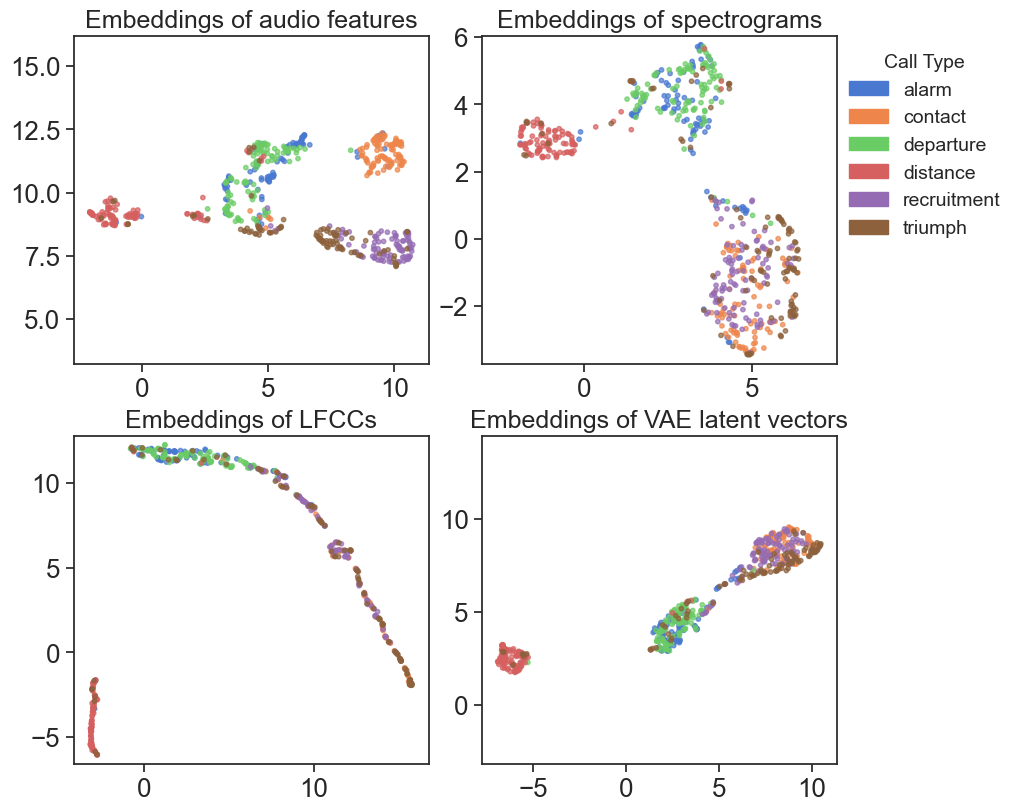

In [ ]:
# from matplotlib.patches import Patch

# embeddings = [embeddings_paf, embeddings_spec, embeddings_lfcc, embeddings_vae]
# titles = ["Embeddings of audio features", "Embeddings of spectrograms", "Embeddings of LFCCs", "Embeddings of VAE latent vectors"]
# unique_call_types = subset_df["call_type"].unique()
# color_palette = sns.color_palette("muted", len(unique_call_types))
# label_to_color = {label: color for label, color in zip(unique_call_types, color_palette)}
# legend_patches = [Patch(color=color, label=label) for label, color in CALL_TYPE_COLORS.items()]
# colors = [CALL_TYPE_COLORS[label] for label in subset_df["call_type"]]

# cols = 2
# rows = 2

# fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), constrained_layout=True)
# axes = axes.flatten()

# for i, (embedding, title) in enumerate(zip(embeddings, titles)):
#     ax = axes[i]

#     ax.scatter(
#         embedding[:, 0],
#         embedding[:, 1],
#         c=colors,
#         alpha=0.7,
#         s=DOT_SIZE
#     )
#     if i == 1:  
#         ax.legend(
#             handles=legend_patches,
#             title="Call Type",
#             fontsize=14,
#             title_fontsize=14,
#             bbox_to_anchor=(1.51, 1), 
#             loc="upper right",
#             frameon=False,
#         )
    
#     ax.set_title(title, fontsize=18)
#     ax.set_aspect('equal', 'datalim')

# plt.show()

In [ ]:
cluster_labels = [labels_kMeans_paf, subset_df["call_type"], labels_HDBSCAN_paf, labels_Leiden_paf]
titles = ["k-means", "Original Call Type Labels", "HDBSCAN", "Leiden"]

cols = 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), constrained_layout=True)
axes = axes.flatten()

for i, (cluster_label_list, title) in enumerate(zip(cluster_labels, titles)):
    unique_labels = np.unique(cluster_label_list)
    if i == 1:
        color_palette = sns.color_palette("muted", len(np.unique(cluster_label_list)))
    else:
        color_palette = sns.color_palette("Set2", len(np.unique(cluster_label_list)))  
    
    label_to_color = {label: color for label, color in zip(unique_labels, color_palette)}  
    colors = [label_to_color[label] for label in cluster_label_list] 

    ax = axes[i]

    ax.scatter(
        embeddings_paf[:, 0],
        embeddings_paf[:, 1],
        c=colors,
        alpha=0.7,
        s=DOT_SIZE
    )
    # if i == 1:  
    ax.legend(
        handles=legend_patches,
        title="Call Type",
        fontsize=14,
        title_fontsize=14,
        bbox_to_anchor=(1.5, 1), 
        loc="upper right",
        frameon=False,
    )
    ax.set_yticklabels([])
    
    if i < 2:
        ax.set_xticklabels([])
    
    if i == 3:
        ax.set_yticklabels([])
    
    ax.set_title(title, fontsize=18)
    ax.set_aspect('equal', 'datalim')

plt.show()

NameError: name 'labels_kMeans_paf' is not defined

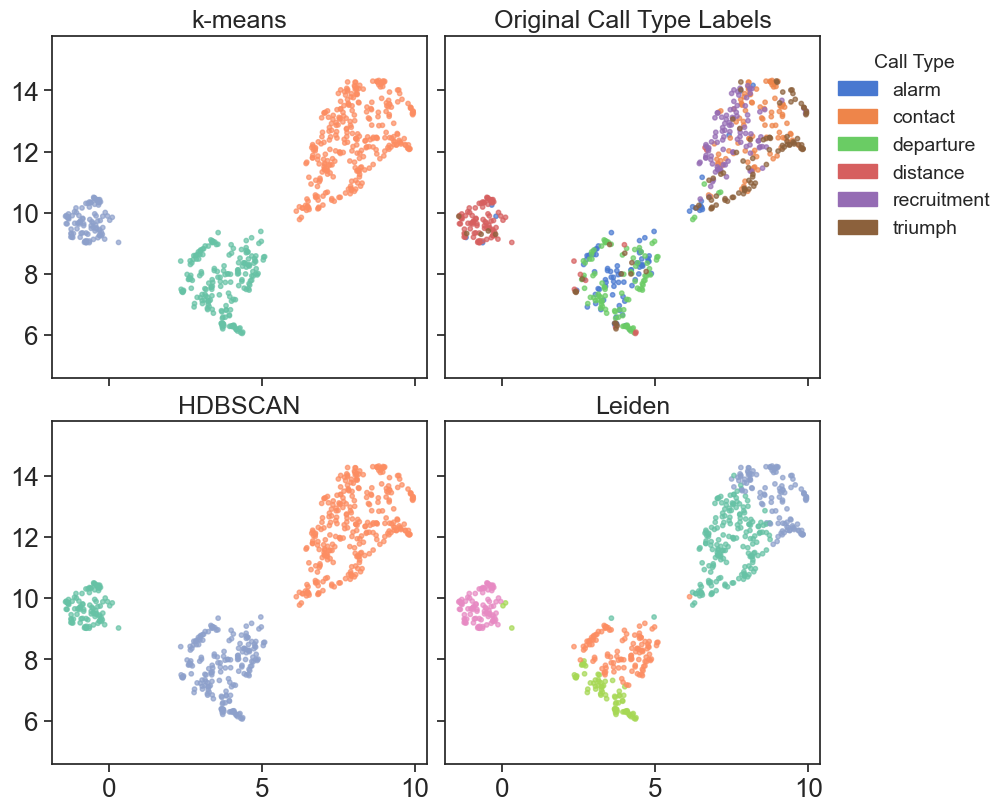

In [ ]:
cluster_labels = [labels_kMeans_spec, subset_df["call_type"], labels_HDBSCAN_spec, labels_Leiden_spec]
titles = ["k-means", "Original Call Type Labels", "HDBSCAN", "Leiden"]

cols = 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), constrained_layout=True)
axes = axes.flatten()

for i, (cluster_label_list, title) in enumerate(zip(cluster_labels, titles)):
    unique_labels = np.unique(cluster_label_list)
    if i == 1:
        color_palette = sns.color_palette("muted", len(np.unique(cluster_label_list)))
    else:
        color_palette = sns.color_palette("Set2", len(np.unique(cluster_label_list)))  
    
    label_to_color = {label: color for label, color in zip(unique_labels, color_palette)}  
    colors = [label_to_color[label] for label in cluster_label_list] 

    ax = axes[i]

    ax.scatter(
        embeddings_spec[:, 0],
        embeddings_spec[:, 1],
        c=colors,
        alpha=0.7,
        s=DOT_SIZE
    )
    if i == 1:  
        ax.legend(
            handles=legend_patches,
            title="Call Type",
            fontsize=14,
            title_fontsize=14,
            bbox_to_anchor=(1.5, 1), 
            loc="upper right",
            frameon=False
        )
        ax.set_yticklabels([])
    
    if i < 2:
        ax.set_xticklabels([])
    
    if i == 3:
        ax.set_yticklabels([])
    
    ax.set_title(title, fontsize=18)
    ax.set_aspect('equal', 'datalim')

plt.show()

In [ ]:
# plotting.plot_cluster_examples("leiden_cluster_paf", np.unique(labels_Leiden_paf), subset_df)
# plotting.plot_cluster_examples("leiden_cluster_lfcc", np.unique(labels_Leiden_lfcc), subset_df)
# plotting.plot_cluster_examples("leiden_cluster_spectrogram", np.unique(labels_Leiden_spec), subset_df)
# plotting.plot_cluster_examples("leiden_cluster_vae", np.unique(labels_Leiden_vae), subset_df)

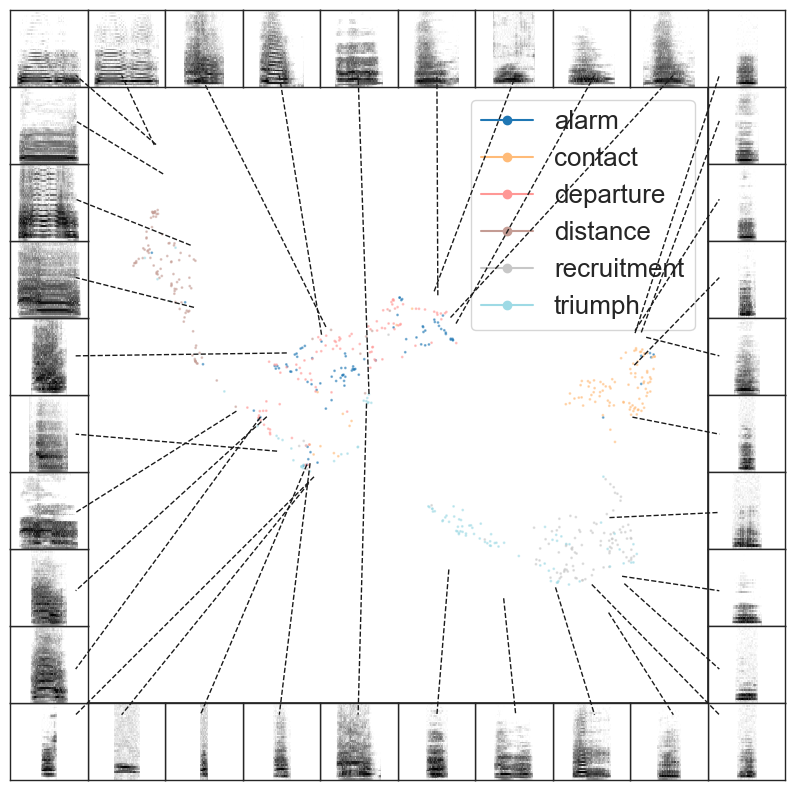

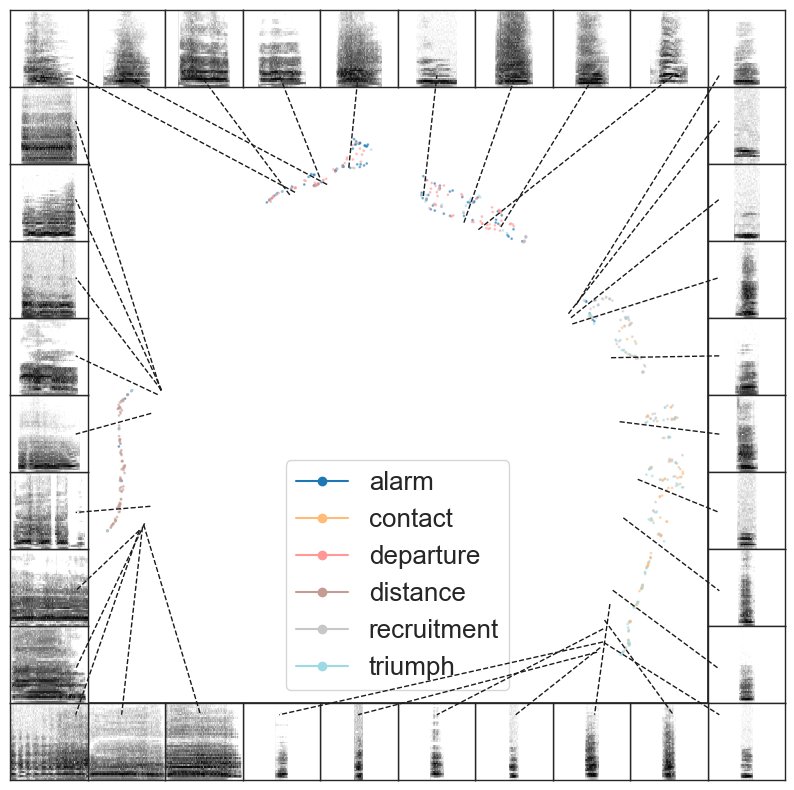

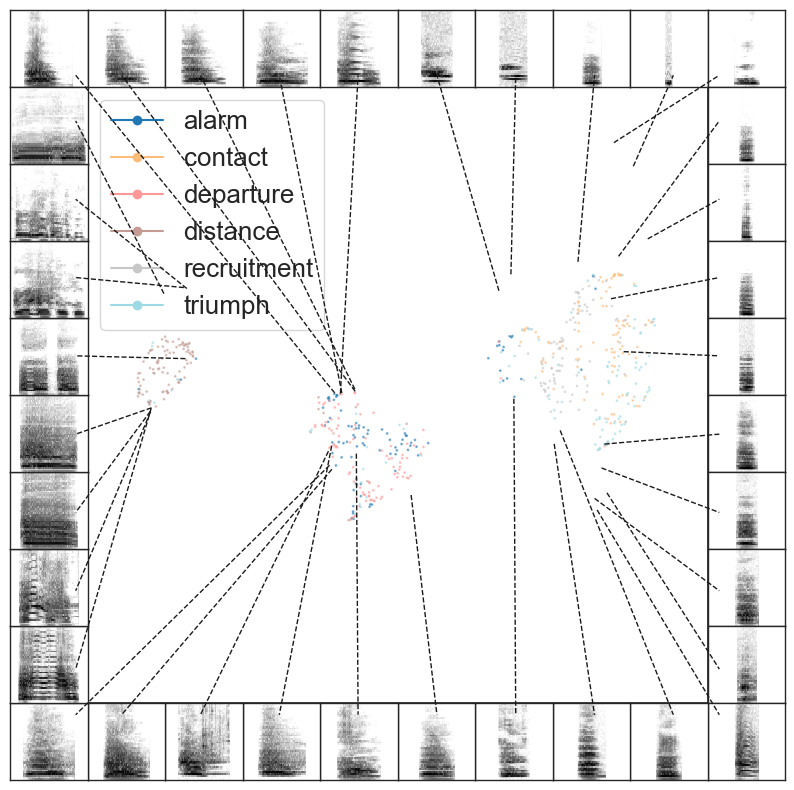

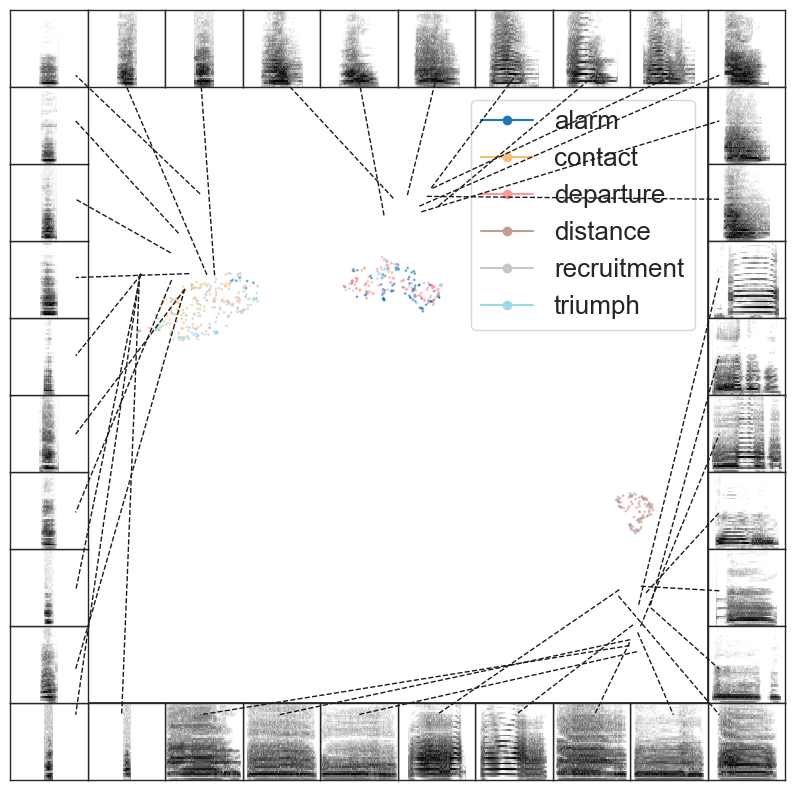

In [ ]:
plotting.scatter_spec(embeddings_paf, subset_df["log_padded_spectrogram"], scatter_kwargs={"alpha": 0.5, "s": 1, "labels": subset_df["call_type"]})
plotting.scatter_spec(embeddings_lfcc, subset_df["log_padded_spectrogram"], scatter_kwargs={"alpha": 0.5, "s": 1, "labels": subset_df["call_type"]})
plotting.scatter_spec(embeddings_spec, subset_df["log_padded_spectrogram"], scatter_kwargs={"alpha": 0.5, "s": 1, "labels": subset_df["call_type"]})
plotting.scatter_spec(embeddings_vae, subset_df["log_padded_spectrogram"], scatter_kwargs={"alpha": 0.5, "s": 1, "labels": subset_df["call_type"]})

In [ ]:
# # export results_df
# results_df.to_csv("pickles_and_csvs/results_resampled_50_new.csv", index=False)

# Inspect metrics

In [ ]:
results_df = pd.read_csv("pickles_and_csvs/results_resampled_50.csv")
results_df.head()

,Representation,Algorithm,Distance metric,Subset size,N clusters,V-measure,Adj. RS,Hopkins,Silhouette Score,Modularity,Homogeneity,Completeness,Trustworthiness,Continuity
0,PAF,kMeans-preset,euclidean,50,5,0.471812,0.378026,0.886159,0.248973,NaN,0.445240,0.501758,0.947545,0.946080
1,PAF,kMeans,euclidean,50,7,0.504001,0.396656,0.886159,0.248973,NaN,0.520790,0.488261,0.947545,0.946080
2,PAF,HDBSCAN,euclidean,50,26,0.490537,0.262366,0.886159,0.248973,NaN,0.667573,0.387717,0.947545,0.946080
3,PAF,Leiden,euclidean,50,7,0.502136,0.403769,0.886159,0.521548,0.689949,0.520683,0.484865,0.947545,0.946080
4,LFCC,kMeans-preset,euclidean,50,5,0.390431,0.233407,0.987553,0.381445,NaN,0.362534,0.422980,0.981698,0.986284


In [ ]:
results_df = results_df.replace("kMeans", "k-means", regex=True)
results_df = results_df.replace("PAF", "Audio Features", regex=True)

In [ ]:
results_df = results_df[
    ~((results_df["Algorithm"] == "Leiden-preset") & 
      (results_df["Subset size"] > 100) &
       (results_df["N clusters"] == 6))
]
results_df = results_df[
    ~((results_df["Algorithm"] == "Leiden-preset") & 
      (results_df["Subset size"] <= 100) &
       (results_df["N clusters"] == 5))
]

In [ ]:
results_df_inc_manhattan = results_df.copy()
results_df = results_df[results_df["Distance metric"]=="euclidean"].reset_index(drop=True)

In [ ]:
len(results_df)

3280

In [ ]:
results_df['Subset size'] = results_df['Subset size'].replace(4000, 'complete dataset')
results_df['Representation'] = results_df['Representation'].replace('lfcc', 'LFCC')

/var/folders/kl/qgqbw3bd42bf_tybhvnz9vxh0000gn/T/ipykernel_20303/1899200836.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["Audio Features", "LFCC", "Spectrogram", "VAE"], rotation=45, ha='right')
/var/folders/kl/qgqbw3bd42bf_tybhvnz9vxh0000gn/T/ipykernel_20303/1899200836.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["Audio Features", "LFCC", "Spectrogram", "VAE"], rotation=45, ha='right')
/var/folders/kl/qgqbw3bd42bf_tybhvnz9vxh0000gn/T/ipykernel_20303/1899200836.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["Audio Features", "LFCC", "Spectrogram", "VAE"], rotation=45, ha='right')
/var/folders/kl/qgqbw3bd42bf_tybhvnz9vxh0000gn

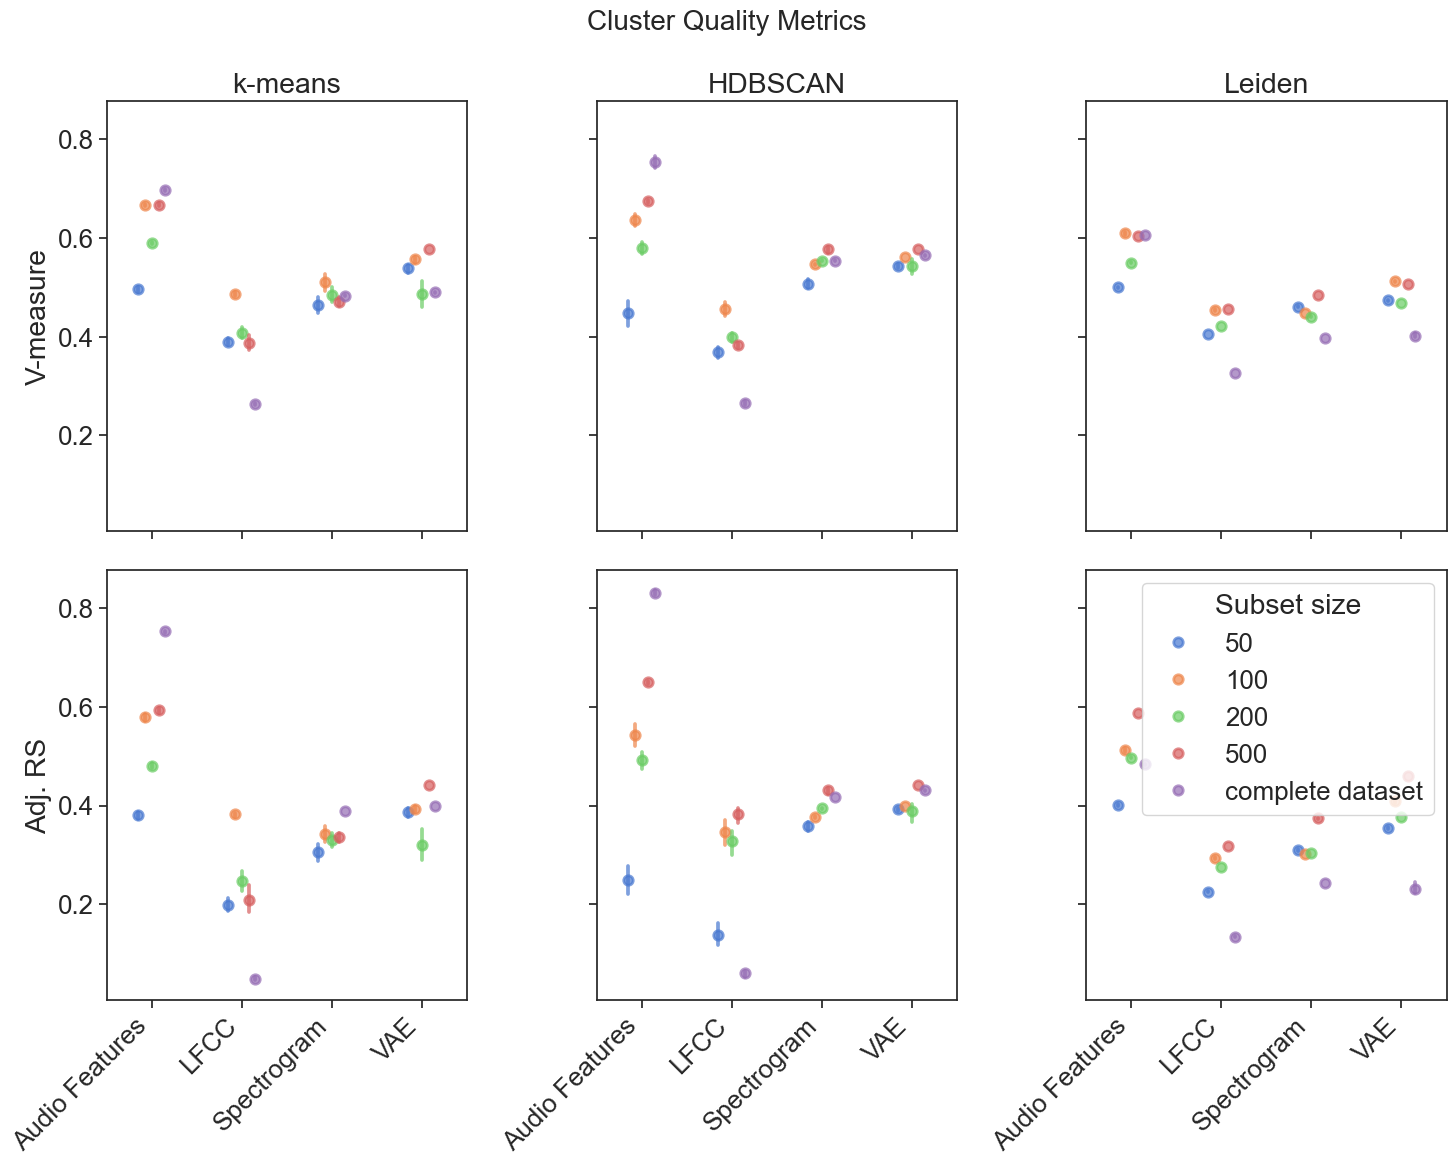

In [ ]:
rows = ["V-measure", "Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["Audio Features", "LFCC", "Spectrogram", "VAE"]

subset_labels = results_df["Subset size"].unique()
subset_labels = ['complete dataset' if x == 4000 else x for x in subset_labels]

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 12), sharex=True, sharey=True)
for row, metric in enumerate(rows):
    for col, representation in enumerate(columns):
        data = results_df[results_df["Algorithm"] == representation]

        sns.pointplot(
            x="Representation", 
            y=metric,  
            data=data, 
            ax=axs[row, col], 
            hue="Subset size", 
            linestyle="none",
            alpha=.7,
            errorbar="ci",
            dodge=.3,
            legend=(True if col==2 and row==1 else False),
            palette="muted"
        )

        if row == 0:
            axs[row, col].set_title(representation)

        #axs[row, col].set_ylim(0.1, 0.7)
        axs[row, col].set_xticklabels(["Audio Features", "LFCC", "Spectrogram", "VAE"], rotation=45, ha='right')
        axs[row, col].set_xlabel("")

        if col == 0:
            axs[row, col].set_ylabel(metric)  # Label only the first column
        else:
            axs[row, col].set_ylabel('')

fig.suptitle("Cluster Quality Metrics", fontsize=20)
plt.tight_layout()
plt.show()

/var/folders/kl/qgqbw3bd42bf_tybhvnz9vxh0000gn/T/ipykernel_20303/3430847035.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(representations, rotation=45, ha='right', fontsize=24)
/var/folders/kl/qgqbw3bd42bf_tybhvnz9vxh0000gn/T/ipykernel_20303/3430847035.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(representations, rotation=45, ha='right', fontsize=24)
/var/folders/kl/qgqbw3bd42bf_tybhvnz9vxh0000gn/T/ipykernel_20303/3430847035.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(representations, rotation=45, ha='right', fontsize=24)
/var/folders/kl/qgqbw3bd42bf_tybhvnz9vxh0000gn/T/ipykernel_20303/3430847035.py:28: UserWarning: set_tickla

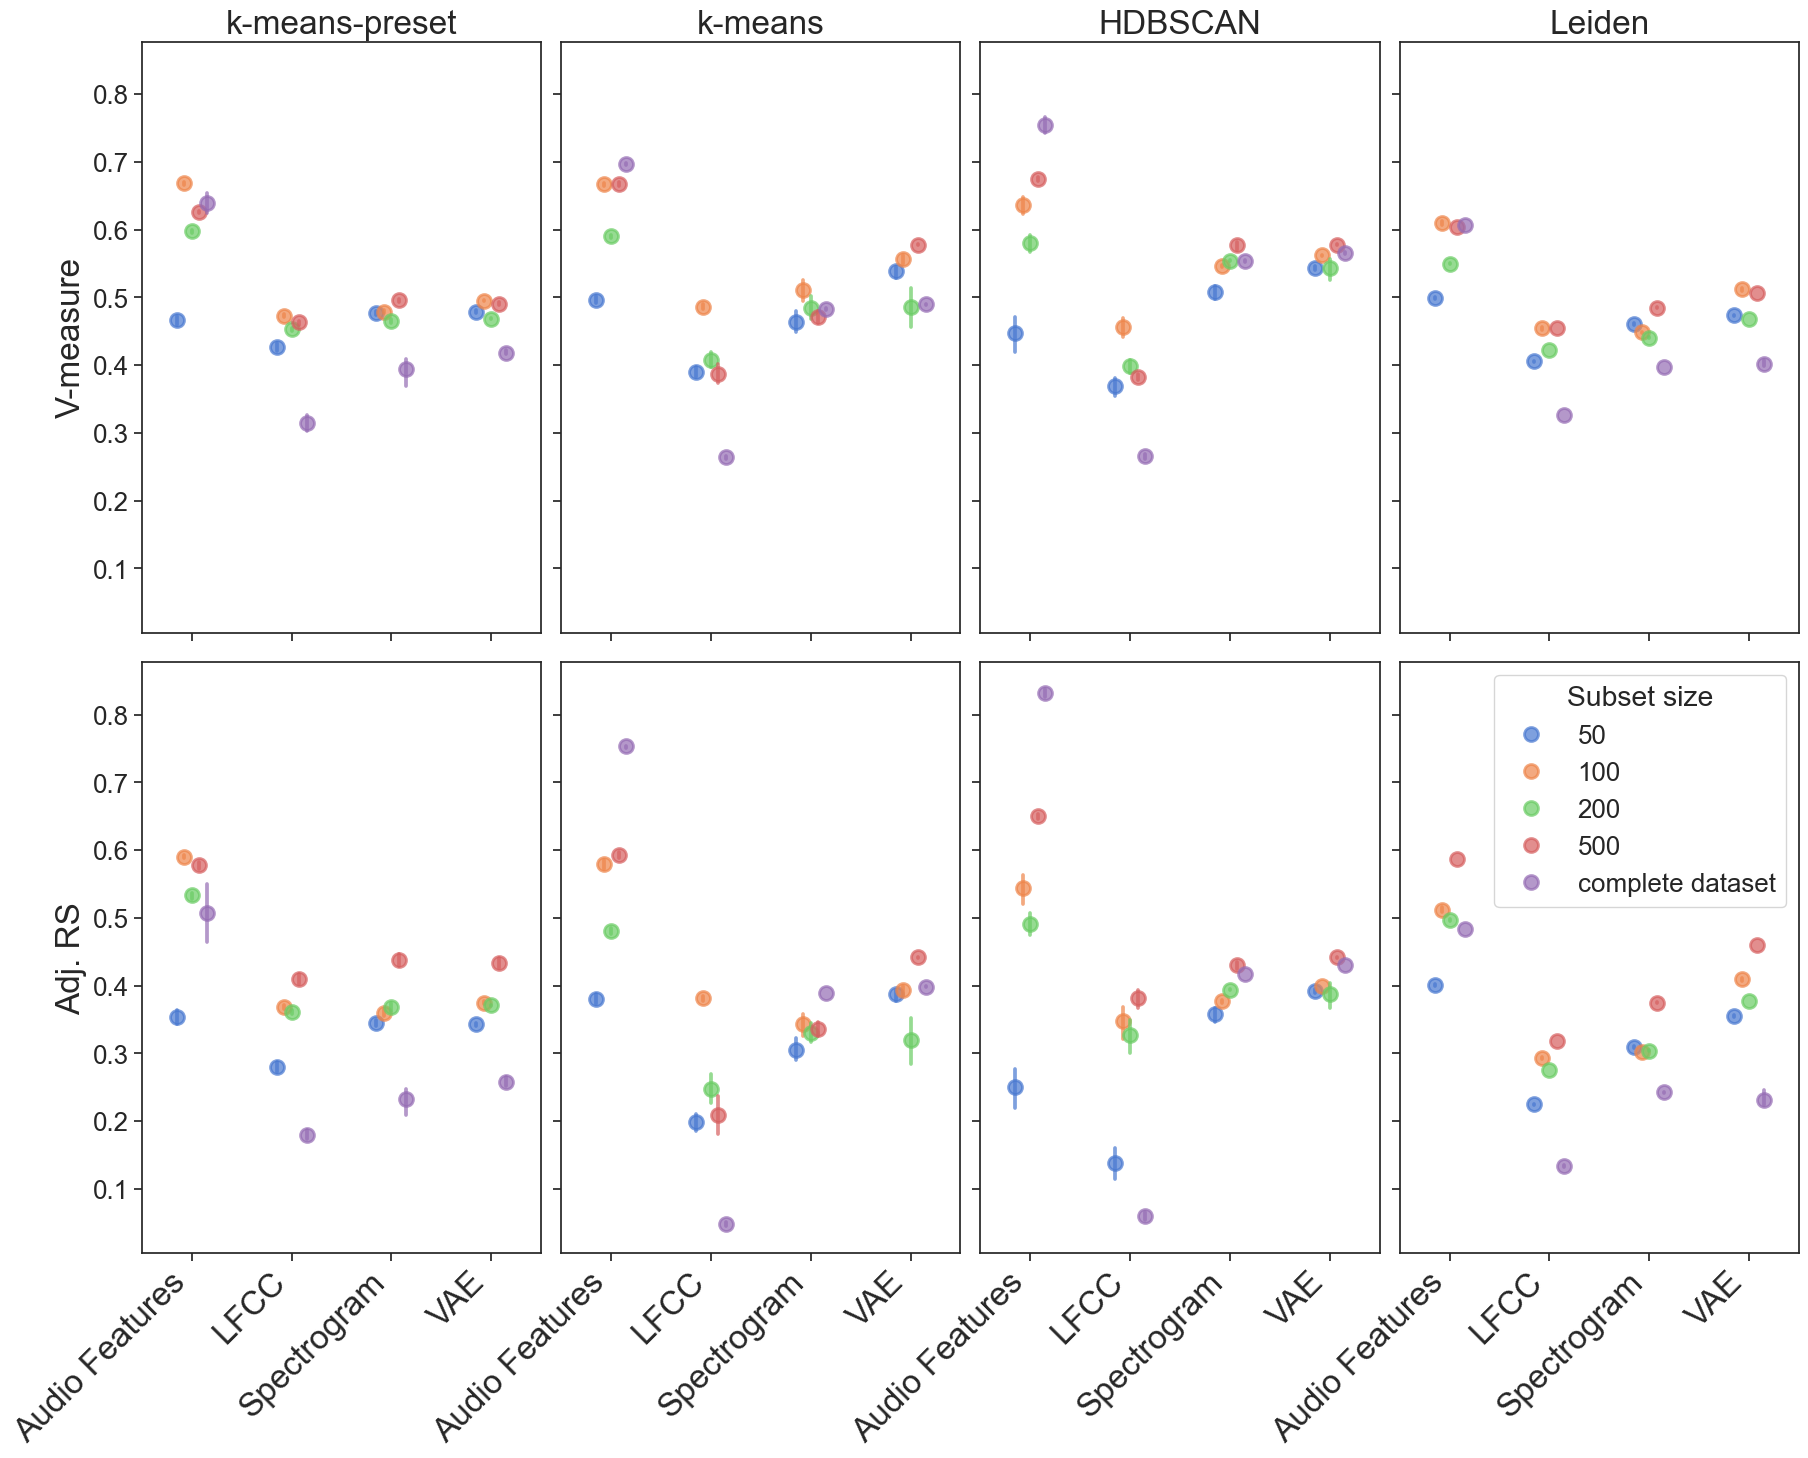

In [ ]:
rows = ["V-measure", "Adj. RS"]
columns = ["k-means-preset", "k-means", "HDBSCAN", "Leiden"]
representations = ["Audio Features", "LFCC", "Spectrogram", "VAE"]

fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(17, 15), sharex=True, sharey=True)
for row, metric in enumerate(rows):
    for col, representation in enumerate(columns):
        data = results_df[results_df["Algorithm"] == representation]

        sns.pointplot(
            x="Representation", 
            y=metric,  
            data=data, 
            ax=axs[row, col], 
            hue="Subset size", 
            linestyle="none",
            alpha=.7,
            errorbar="ci",
            dodge=.3,
            legend=(True if row==1 and col==3 else False),
            palette="muted",
            markersize=10,
        )

        if row == 0:
            axs[row, col].set_title(representation, fontsize=24)

        axs[row, col].set_xticklabels(representations, rotation=45, ha='right', fontsize=24)
        axs[row, col].set_xlabel("")

        if col == 0:
            axs[row, col].set_ylabel(metric, fontsize=24)
        else:
            axs[row, col].set_ylabel('')

# fig.suptitle("Cluster Quality Metrics", fontsize=28)

# legend_ax = axs[1, 3].get_legend()
# if legend_ax:
#     legend_ax.set_frame_on(False)

plt.tight_layout()
plt.tight_layout(rect=[0, 0, 1.1, 1.1])
plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()

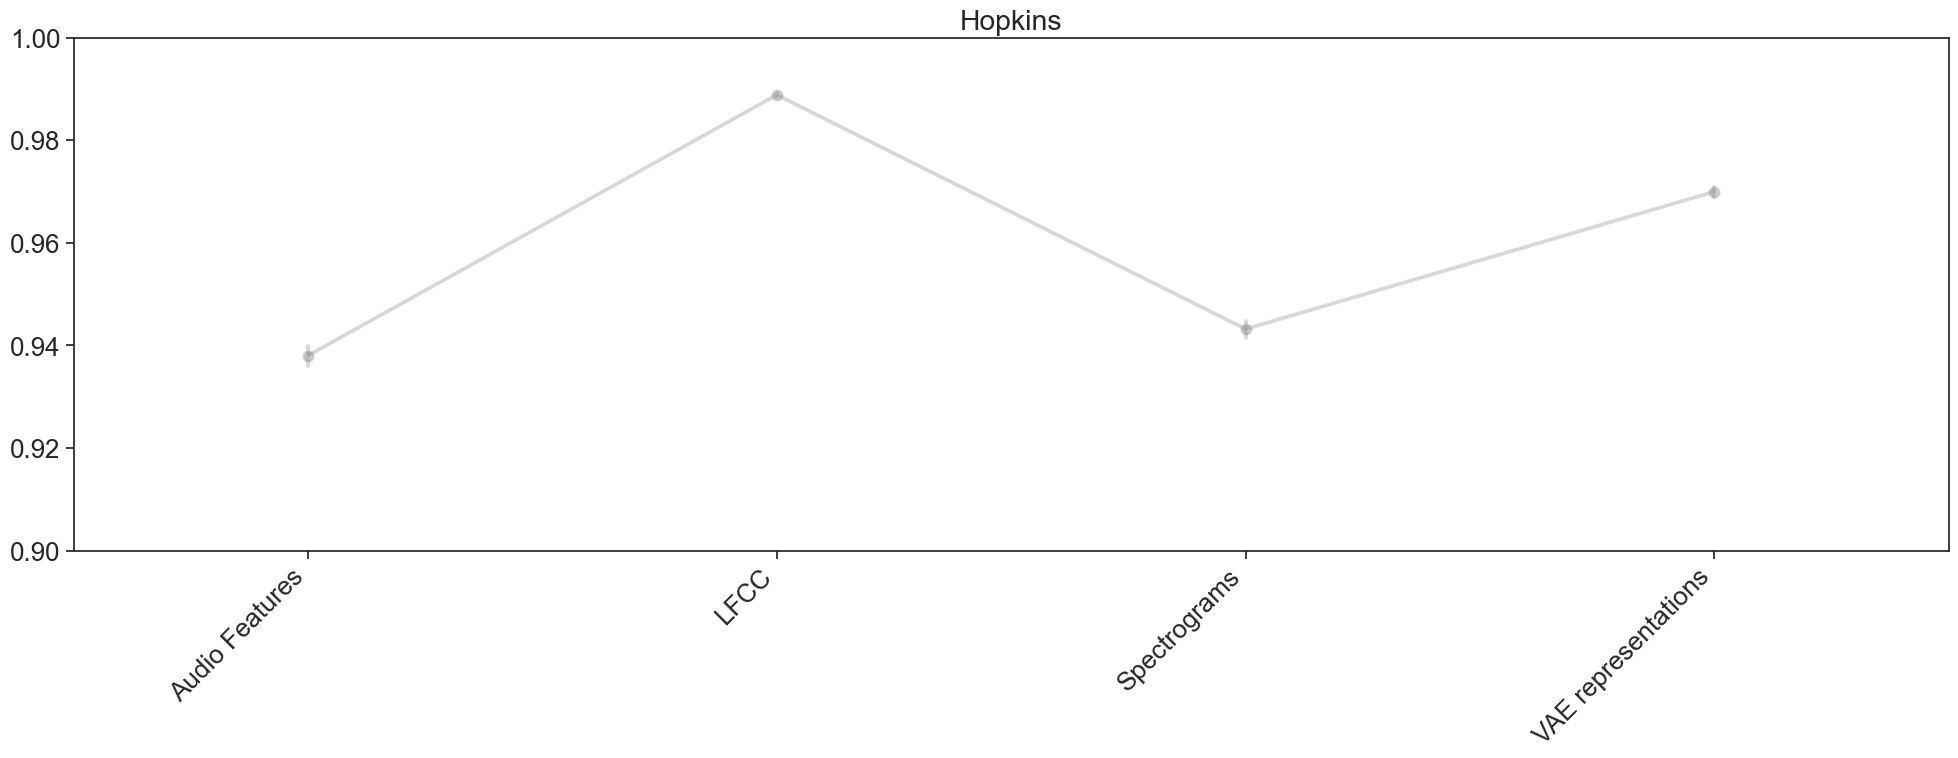

In [ ]:
fig, axs = plt.subplots(ncols=1, figsize=(20, 8))

columns = ["Hopkins"]
for i, column in enumerate(columns):
    # # Raw data points
    # sns.stripplot(
    #     x="Representation", 
    #     y=column, 
    #     data=results_df, 
    #     ax=axs[i], 
    #     jitter=True, 
    #     size=10, 
    #     hue="Algorithm", 
    #     alpha=0.5, 
    #     legend=(True if i == len(columns)-1 else False)
    # )
    
    # Mean points
    sns.pointplot(
        x="Representation", 
        y=column, 
        data=results_df, 
        ax=axs, 
        errorbar="ci",
        markers="o", 
        color="grey",
        alpha=.3
    )

    axs.set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
    axs.set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], rotation=45, ha='right')
    axs.set_title(column)
    axs.set_xlabel('')
    axs.set_ylabel('')
    axs.set_ylim(0.9, 1)

plt.tight_layout()
plt.show()
# Homogeneity: measures to what proportion clusters contain only data points with the same label
# Completensess: measures if all members of the same class are also members of the same cluster

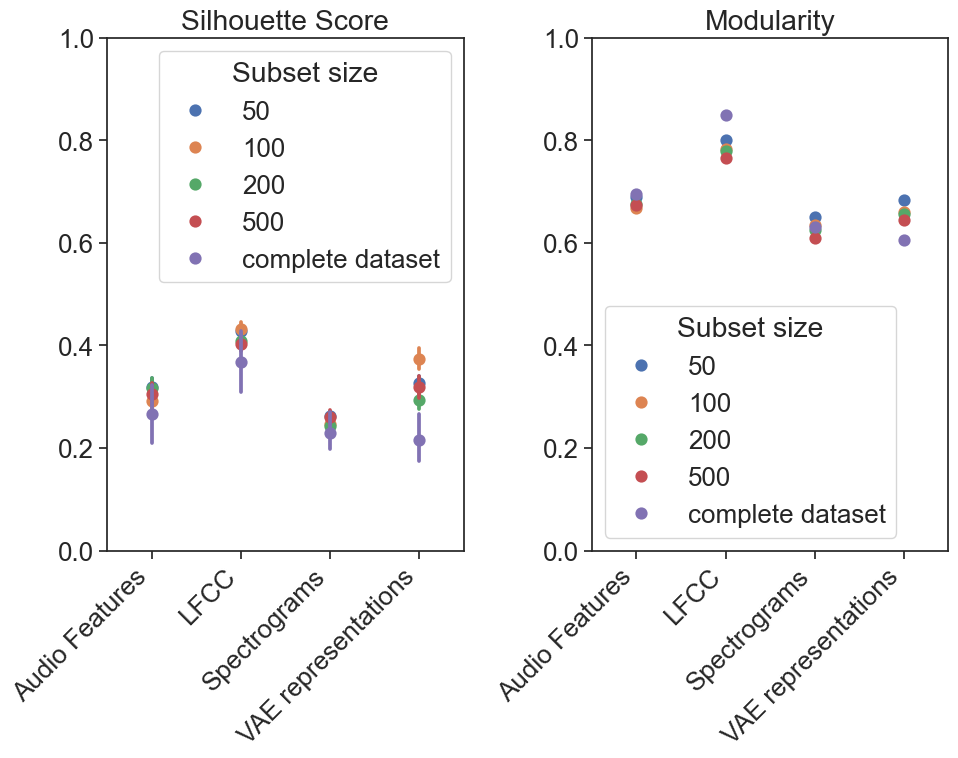

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(10, 8))

columns = ["Silhouette Score", "Modularity"]
for i, column in enumerate(columns):
    # Mean points
    sns.pointplot(
        x="Representation", 
        y=column, 
        data=results_df[results_df["Algorithm"]=="Leiden"] if column=="Modularity" else results_df[~results_df.isin({"Algorithm": ["k-means-preset", "Leiden"]})], 
        ax=axs[i], 
        hue="Subset size",
        linestyle="none",
        errorbar="ci",
    )

    axs[i].set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
    axs[i].set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], rotation=45, ha='right')
    axs[i].set_title(column)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].set_ylim(0, 1)

plt.tight_layout()
plt.show()
# Homogeneity: measures to what proportion clusters contain only data points with the same label
# Completensess: measures if all members of the same class are also members of the same cluster

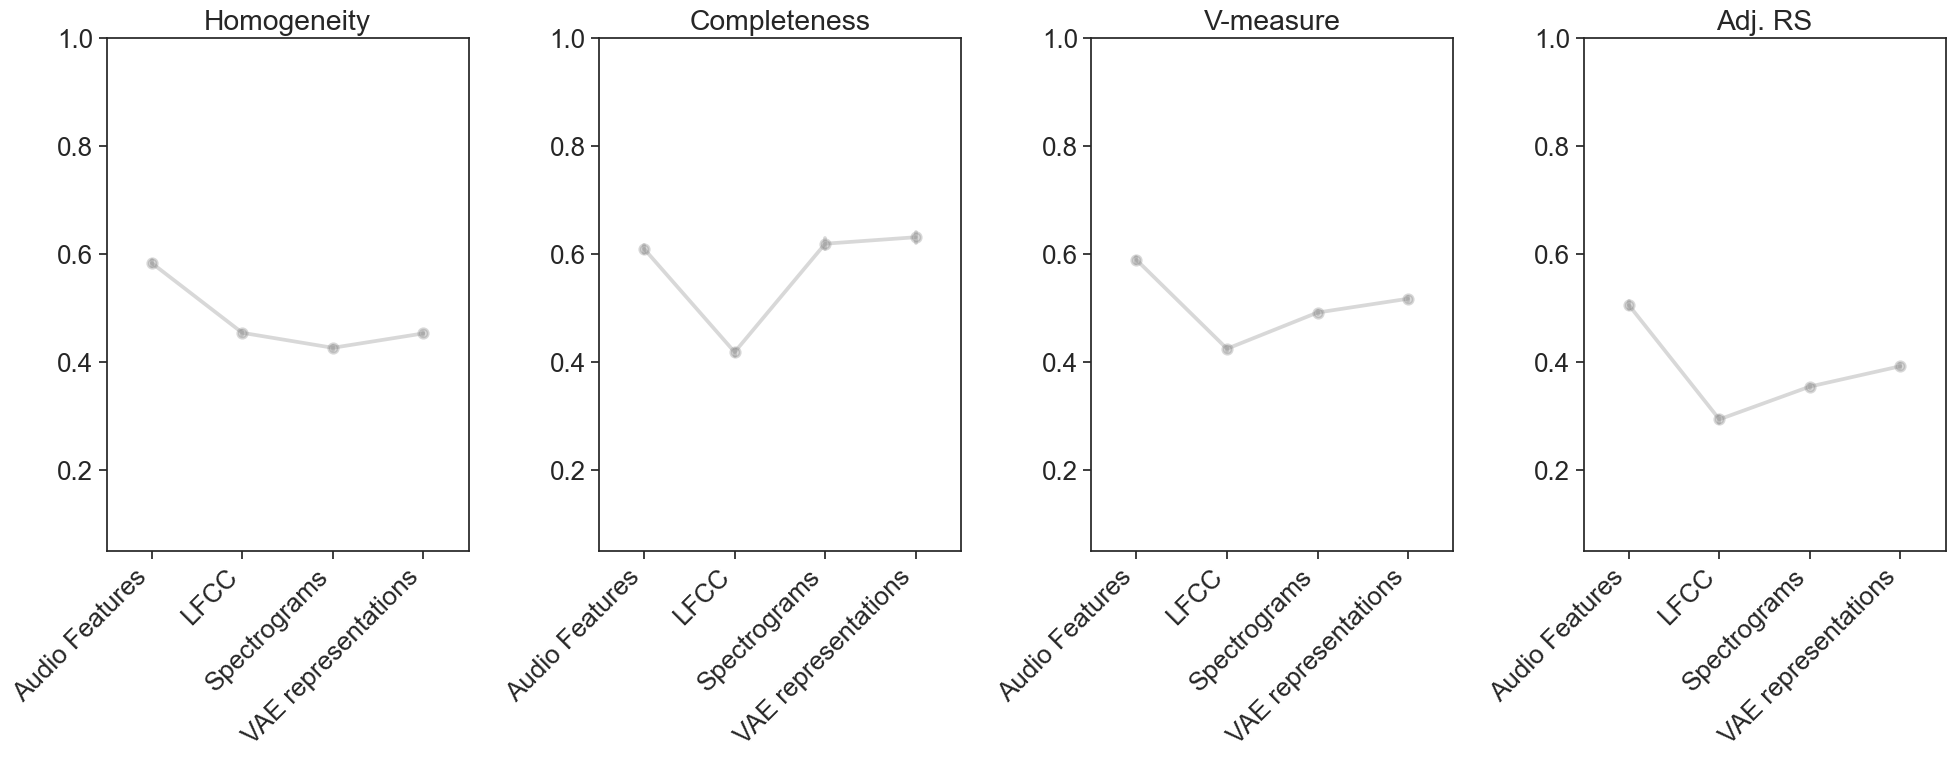

In [ ]:
fig, axs = plt.subplots(ncols=4, figsize=(20, 8))

columns = ["Homogeneity", "Completeness", "V-measure", "Adj. RS"]
for i, column in enumerate(columns):
    
    # Mean points
    sns.pointplot(
        x="Representation", 
        y=column, 
        data=results_df, 
        ax=axs[i], 
        errorbar="ci",
        markers="o", 
        color="grey",
        alpha=.3
    )

    axs[i].set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
    axs[i].set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], rotation=45, ha='right')
    axs[i].set_title(column)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].set_ylim(0.05, 1)

plt.tight_layout()
plt.show()
# Homogeneity: measures to what proportion clusters contain only data points with the same label
# Completensess: measures if all members of the same class are also members of the same cluster

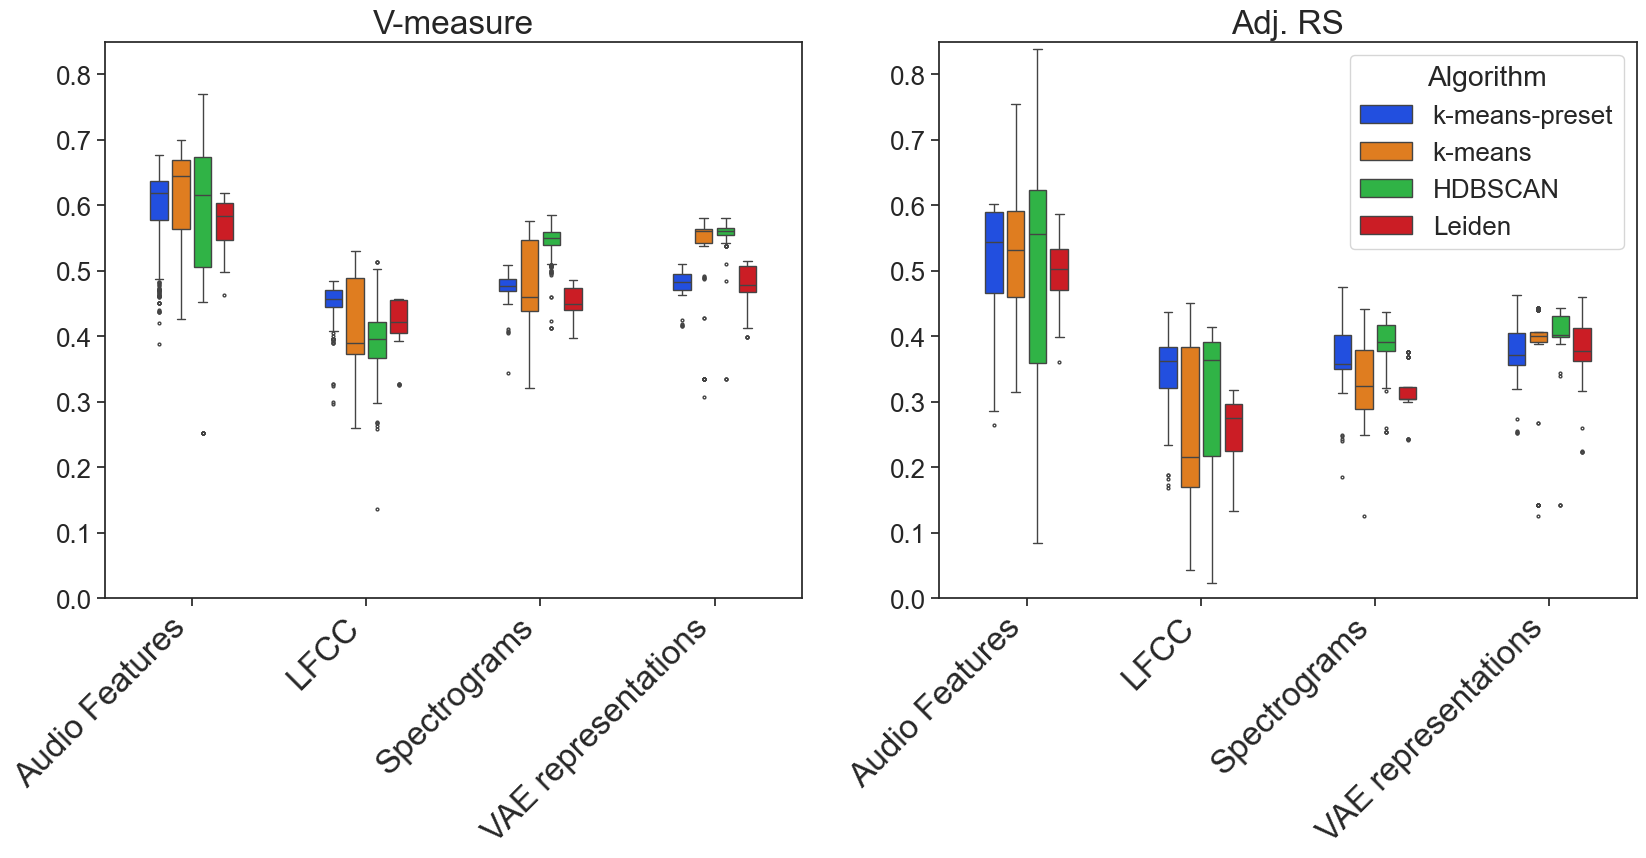

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(17, 9))

columns = ["V-measure", "Adj. RS"]
for i, column in enumerate(columns):
    sns.boxplot(
        x="Representation", 
        y=column, 
        data=results_df, 
        ax=axs[i], 
        hue="Algorithm", 
        legend=True if i == len(columns)-1 else False,
        gap=.2,
        fliersize=2,
        width=.5,
        palette="bright"
    )
    
    axs[i].set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
    axs[i].set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], rotation=45, ha='right', fontsize=24)
    axs[i].set_title(column, fontsize=24)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].set_ylim(.0, .85)

plt.tight_layout()
plt.show()


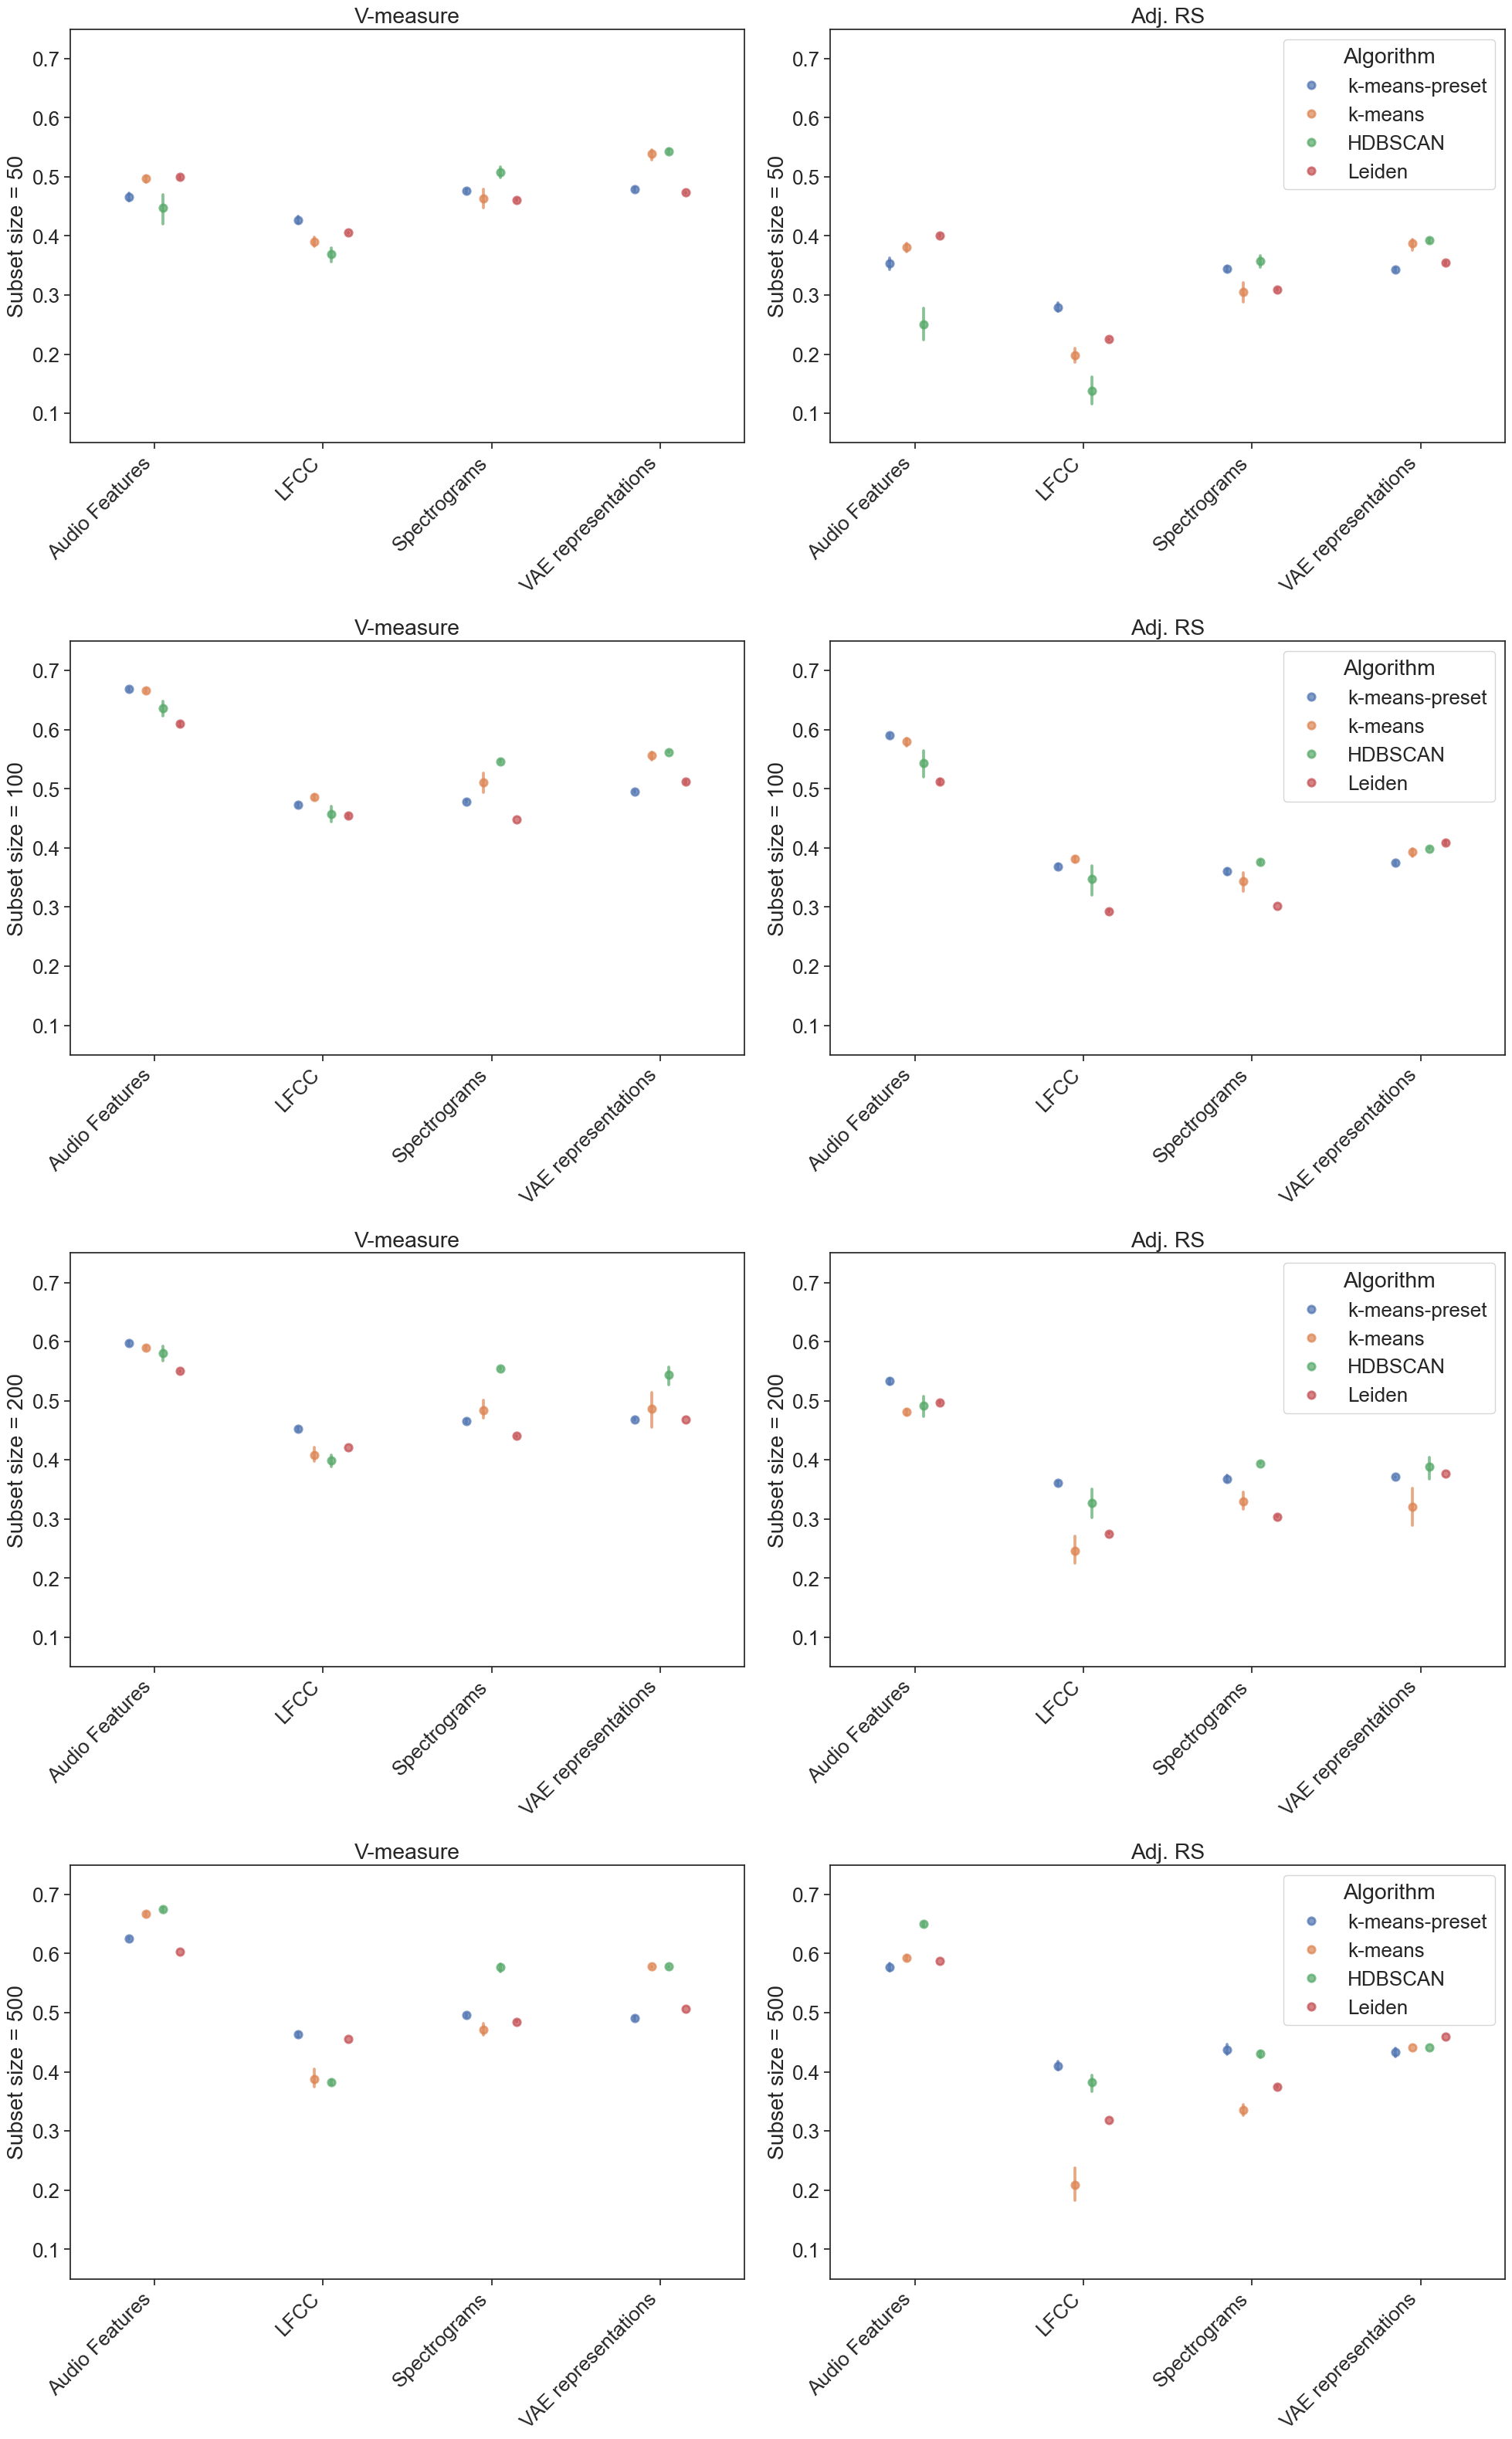

In [ ]:
fig, axs = plt.subplots(ncols=2, nrows=4, figsize=(20, 8*4))

columns = ["V-measure", "Adj. RS"]
for j, sub_size in enumerate([50, 100, 200, 500]):
    for i, column in enumerate(columns):
        # Raw datapoints
        sns.pointplot(
            x="Representation", 
            y=column, 
            data=results_df[results_df["Subset size"]==sub_size], 
            ax=axs[j, i], 
            hue="Algorithm", 
            legend=(True if i == len(columns)-1 else False),
            linestyle="none",
            alpha=.7,
            errorbar="ci",
            dodge=.3,
        )
    
        axs[j,i].set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
        axs[j,i].set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], rotation=45, ha='right')
        axs[j,i].set_title(column)
        axs[j,i].set_xlabel('')
        axs[j,i].set_ylabel(f"Subset size = {sub_size}")
        axs[j,i].set_ylim(.05, .75)

plt.tight_layout()
plt.show()


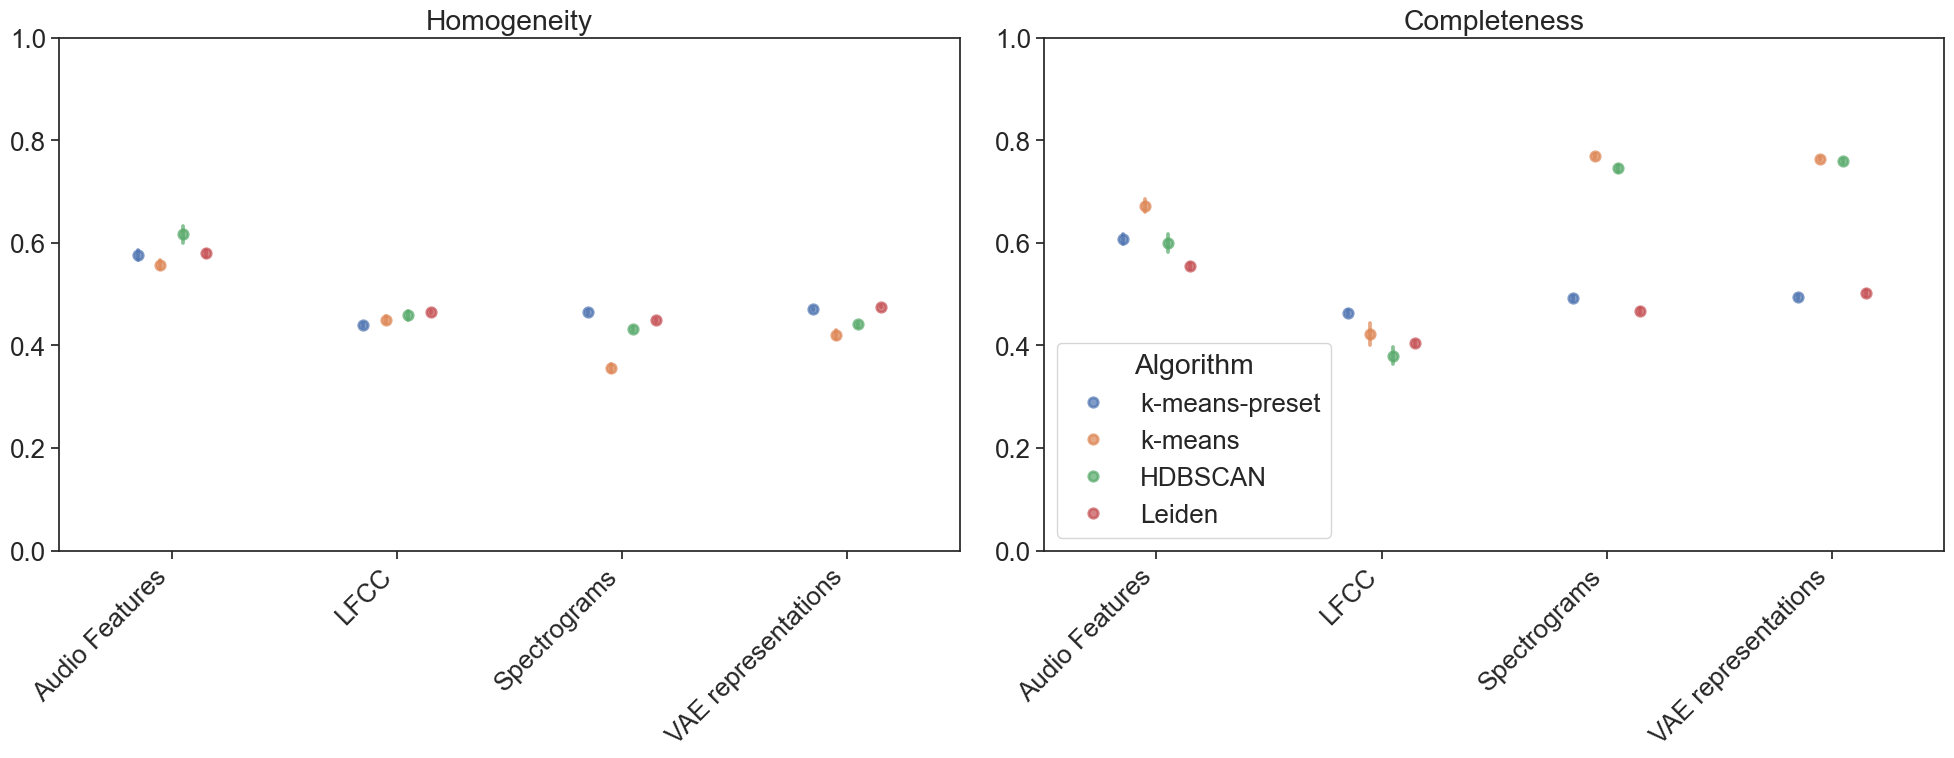

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(20, 8))

columns = ["Homogeneity", "Completeness"]
for i, column in enumerate(columns):
    # Raw datapoints
    sns.pointplot(
        x="Representation", 
        y=column, 
        data=results_df, 
        ax=axs[i], 
        hue="Algorithm", 
        legend=(True if i == len(columns)-1 else False),
        linestyle="none",
        alpha=.7,
        errorbar="ci",
        dodge=.3,
    )
    
    axs[i].set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
    axs[i].set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], rotation=45, ha='right')
    axs[i].set_title(column)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].set_ylim(0.0, 1)

plt.tight_layout()
plt.show()
# Homogeneity: measures to what proportion clusters contain only data points with the same label
# Completensess: measures if all members of the same class are also members of the same cluster

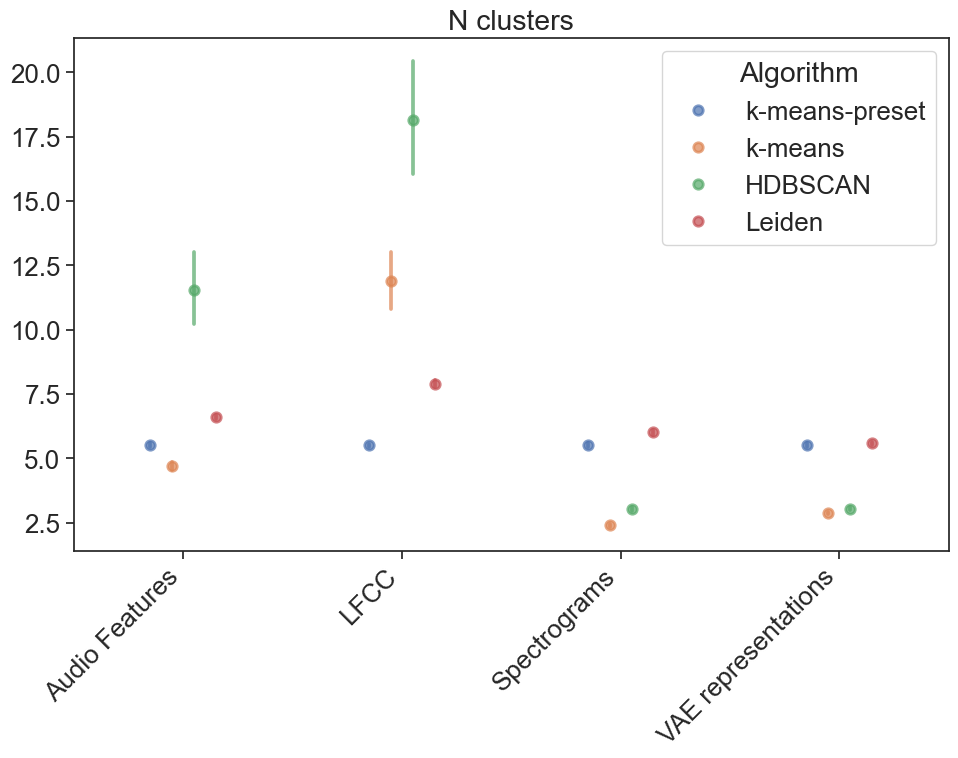

In [ ]:
fig, axs = plt.subplots(ncols=1, figsize=(10, 8))

columns = ["N clusters"]
for i, column in enumerate(columns):
    sns.pointplot(
        x="Representation", 
        y=column, 
        data=results_df, 
        ax=axs, 
        hue="Algorithm", 
        legend=(True if i == len(columns)-1 else False),
        linestyle="none",
        alpha=.7,
        errorbar="ci",
        dodge=.3,
    )
    
    axs.set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
    axs.set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], rotation=45, ha='right')
    axs.set_title(column)
    axs.set_xlabel('')
    axs.set_ylabel('')
    #axs.set_ylim(0.0, 1)

plt.tight_layout()
plt.show()
# Homogeneity: measures to what proportion clusters contain only data points with the same label
# Completensess: measures if all members of the same class are also members of the same cluster

In [ ]:
results_df.iloc[results_df["N clusters"].idxmax()]

Representation           LFCC
Algorithm             HDBSCAN
Distance metric     euclidean
Subset size                50
N clusters                 59
V-measure            0.367517
Adj. RS              0.054211
Hopkins              0.981803
Silhouette Score     0.387679
Modularity                NaN
Homogeneity          0.592031
Completeness         0.266466
Trustworthiness       0.98241
Continuity           0.989215
Name: 390, dtype: object

In [ ]:
results_df.iloc[results_df["N clusters"].idxmin()]

Representation      Spectrogram
Algorithm                kMeans
Distance metric       euclidean
Subset size                  50
N clusters                    2
V-measure              0.426184
Adj. RS                0.258888
Hopkins                0.847423
Silhouette Score       0.232947
Modularity                  NaN
Homogeneity            0.295432
Completeness           0.764564
Trustworthiness         0.93146
Continuity             0.957827
Name: 25, dtype: object

In [ ]:
sub_df = results_df[results_df["Algorithm"]!="k-means-preset"]
for rep in ["Audio Features", "LFCC", "Spectrogram", "VAE"]:
    print(rep)
    print(sub_df[sub_df["Representation"]==rep]["N clusters"].min())
    print(sub_df[sub_df["Representation"]==rep]["N clusters"].max())
    print(sub_df[sub_df["Representation"]==rep]["N clusters"].mean())
    print(sub_df[sub_df["Representation"]==rep]["N clusters"].std())

PAF
2
51
7.611382113821138
6.648714740141193
LFCC
2
59
12.642276422764228
10.98809696625183
Spectrogram
2
7
3.8146341463414632
1.6847990111442521
VAE
2
10
3.8341463414634145
1.3305988750075834


In [ ]:
sub_df = results_df[results_df["Algorithm"]!="k-means-preset"]
for algo in ["k-means", "HDBSCAN", "Leiden"]:
    print(algo)
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].min())
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].max())
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].mean())
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].std())
    
    for rep in representations:
        print("  "+rep)
        sub_sub_df = sub_df[sub_df["Representation"]==rep]
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].max())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].min())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].mean())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].std())

kMeans
2
44
5.463414634146342
5.726563687900489
  PAF
10
3
4.702439024390244
1.2062922866463885
  LFCC
44
2
11.873170731707317
8.475079512329996
  Spectrogram
4
2
2.395121951219512
0.49997608742436284
  VAE
3
2
2.8829268292682926
0.3222944998286492
HDBSCAN
2
59
8.934146341463414
11.220644451533964
  PAF
51
2
11.526829268292683
10.305410353025113
  LFCC
59
2
18.146341463414632
15.385186686960777
  Spectrogram
7
2
3.024390243902439
0.46903137975882775
  VAE
10
2
3.0390243902439025
0.531773783901893
Leiden
5
13
6.529268292682927
1.1902624662972274
  PAF
9
6
6.6048780487804875
0.6823945797747649
  LFCC
13
7
7.907317073170732
1.14025931087214
  Spectrogram
7
5
6.024390243902439
0.717013306889972
  VAE
7
5
5.580487804878048
0.5770188396162802


In [ ]:
results_df[results_df["Algorithm"]!="k-means-preset"]["N clusters"].median()

5.0

In [ ]:
results_df[results_df["Algorithm"]!="k-means-preset"]["N clusters"].mean()

6.975609756097561

In [ ]:
results_df[results_df["Algorithm"]!="k-means-preset"]["N clusters"].std()

7.445519533011529

In [ ]:
results_df[results_df["Algorithm"]!="k-means-preset"]["N clusters"].sem()

0.15011616249578816

In [ ]:
sub_df = results_df[results_df["Algorithm"]!="k-means-preset"]
for rep in representations:
    print(rep)
    print(sub_df[sub_df["Representation"]==rep]["Hopkins"].mean())
    print(sub_df[sub_df["Representation"]==rep]["Hopkins"].std())

PAF
0.9380001255535592
0.031622352948912524
LFCC
0.9888248247148657
0.0055069165427913385
Spectrogram
0.9431682998178273
0.02388004250765176
VAE
0.9699646832874881
0.01395117540618913


In [ ]:
sub_df = results_df[~results_df["Algorithm"].isin(["k-means-preset", "Leiden"])]
for rep in representations:
    print(rep)
    print(sub_df[sub_df["Representation"]==rep]["Silhouette Score"].mean())
    print(sub_df[sub_df["Representation"]==rep]["Silhouette Score"].std())

PAF
0.22768038751691205
0.015634496506235853
LFCC
0.3654151724894648
0.017587459599594485
Spectrogram
0.20930962340156672
0.014268455975497338
VAE
0.24855554084680842
0.03196769295173127


In [ ]:
sub_df = results_df[results_df["Algorithm"]=="Leiden"]
for rep in representations:
    print(rep)
    print(sub_df[sub_df["Representation"]==rep]["Modularity"].mean())
    print(sub_df[sub_df["Representation"]==rep]["Modularity"].std())

PAF
0.6775164347756418
0.008484179133445697
LFCC
0.7834993700288282
0.016052934807004773
Spectrogram
0.6299670141148646
0.014379758841159312
VAE
0.6593956358956582
0.016476591817157906


In [ ]:
sub_df = results_df[results_df["Algorithm"]!="k-means-preset"]
for rep in representations:
    print(rep)
    print(sub_df[sub_df["Representation"]==rep]["Adj. RS"].mean())
    print(sub_df[sub_df["Representation"]==rep]["Adj. RS"].std())
    for algo in ["k-means", "HDBSCAN", "Leiden"]:
        print("  "+algo)
        sub_sub_df = sub_df[sub_df["Representation"]==rep]
        print("  ",sub_sub_df[sub_sub_df["Algorithm"]==algo]["Adj. RS"].mean())
        print("  ",sub_sub_df[sub_sub_df["Algorithm"]==algo]["Adj. RS"].std())

PAF
0.5018299360322275
0.11919432621204011
  kMeans
   0.5143397647006517
   0.09525953737884393
  HDBSCAN
   0.4922558770984354
   0.1704385455105902
  Leiden
   0.4988941662975953
   0.06617730883105385
LFCC
0.2737393962884421
0.09943460879865072
  kMeans
   0.2537329187429529
   0.1045792786355718
  HDBSCAN
   0.29286629144421295
   0.12803493364255392
  Leiden
   0.27461897867816054
   0.04072171618487881
Spectrogram
0.34693647424782825
0.051922867757583445
  kMeans
   0.32986349071706494
   0.054404400034883144
  HDBSCAN
   0.3905075517900371
   0.03451079392058068
  Leiden
   0.32043838023638255
   0.03251613105574943
VAE
0.3960519764587434
0.0572940283197944
  kMeans
   0.3861760161052266
   0.0774947056015588
  HDBSCAN
   0.40601915097560204
   0.0379326934408512
  Leiden
   0.39596076229540134
   0.04730568896580655


In [ ]:
sub_df = results_df[results_df["Algorithm"]!="k-means-preset"]
for rep in representations:
    print(rep)
    print(sub_df[sub_df["Representation"]==rep]["V-measure"].mean())
    print(sub_df[sub_df["Representation"]==rep]["V-measure"].std())
    for algo in ["k-means", "HDBSCAN", "Leiden"]:
        print("  "+algo)
        sub_sub_df = sub_df[sub_df["Representation"]==rep]
        print("  ",sub_sub_df[sub_sub_df["Algorithm"]==algo]["V-measure"].mean())
        print("  ",sub_sub_df[sub_sub_df["Algorithm"]==algo]["V-measure"].std())

PAF
0.5876502350878097
0.07960839021611991
  kMeans
   0.6074553407579375
   0.07184795845270063
  HDBSCAN
   0.5887887866657135
   0.10508287945095647
  Leiden
   0.5667065778397778
   0.04509794255526501
LFCC
0.4147560134460921
0.05082654991657265
  kMeans
   0.41420889398431393
   0.05917988948668158
  HDBSCAN
   0.39846656831917915
   0.05468641085800844
  Leiden
   0.43159257803478335
   0.02703093618489181
Spectrogram
0.49537518700775784
0.05403503755280299
  kMeans
   0.48250242997133785
   0.055612103106746996
  HDBSCAN
   0.5465188304237099
   0.032364125397037494
  Leiden
   0.4571043006282262
   0.019518805432441062
VAE
0.5279619460788348
0.05270615956142625
  kMeans
   0.5388585439174807
   0.06537927102698164
  HDBSCAN
   0.5571342880138258
   0.030367810661694132
  Leiden
   0.48789300630519783
   0.024010294048750373


In [ ]:
results_df.iloc[results_df["Trustworthiness"].idxmin()]

Representation                   VAE
Algorithm              kMeans-preset
Distance metric            euclidean
Subset size         complete dataset
N clusters                         6
V-measure                   0.417521
Adj. RS                     0.253577
Hopkins                      0.98827
Silhouette Score            0.148329
Modularity                       NaN
Homogeneity                 0.473137
Completeness                0.373605
Trustworthiness             0.918648
Continuity                  0.937884
Name: 3212, dtype: object

In [ ]:
results_df.iloc[results_df["Trustworthiness"].idxmax()]

Representation                  LFCC
Algorithm              kMeans-preset
Distance metric            euclidean
Subset size         complete dataset
N clusters                         6
V-measure                   0.296053
Adj. RS                     0.168658
Hopkins                     0.997297
Silhouette Score            0.291142
Modularity                       NaN
Homogeneity                 0.330008
Completeness                0.268433
Trustworthiness             0.988741
Continuity                  0.991033
Name: 3204, dtype: object

In [ ]:
results_df.iloc[results_df["Continuity"].idxmax()]

Representation                  LFCC
Algorithm              kMeans-preset
Distance metric            euclidean
Subset size         complete dataset
N clusters                         6
V-measure                    0.32642
Adj. RS                      0.18784
Hopkins                     0.997187
Silhouette Score            0.292938
Modularity                       NaN
Homogeneity                 0.370901
Completeness                0.291467
Trustworthiness             0.986756
Continuity                  0.991161
Name: 3252, dtype: object

In [ ]:
results_df.iloc[results_df["Continuity"].idxmin()]

Representation                   VAE
Algorithm              kMeans-preset
Distance metric            euclidean
Subset size         complete dataset
N clusters                         6
V-measure                   0.425266
Adj. RS                     0.273837
Hopkins                     0.989798
Silhouette Score            0.171262
Modularity                       NaN
Homogeneity                 0.466732
Completeness                0.390566
Trustworthiness              0.91899
Continuity                  0.937708
Name: 3244, dtype: object

In [ ]:
results_df["V-measure"].mean()

0.5048317066988126

In [ ]:
results_df.iloc[results_df["V-measure"].idxmin()]

Representation           LFCC
Algorithm             HDBSCAN
Distance metric     euclidean
Subset size                50
N clusters                  2
V-measure            0.135664
Adj. RS              0.022824
Hopkins              0.982476
Silhouette Score     0.381445
Modularity                NaN
Homogeneity          0.078074
Completeness         0.517055
Trustworthiness      0.981637
Continuity           0.986342
Name: 502, dtype: object

In [ ]:
results_df.iloc[results_df["V-measure"].idxmax()]

Representation                   PAF
Algorithm                    HDBSCAN
Distance metric            euclidean
Subset size         complete dataset
N clusters                         7
V-measure                   0.769191
Adj. RS                       0.8387
Hopkins                     0.981761
Silhouette Score            0.194119
Modularity                       NaN
Homogeneity                 0.769514
Completeness                0.768869
Trustworthiness             0.955039
Continuity                  0.956472
Name: 3234, dtype: object

/var/folders/kl/qgqbw3bd42bf_tybhvnz9vxh0000gn/T/ipykernel_73571/3557129971.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[col].set_xticklabels(representations, rotation=45, ha='right', fontsize=24)
/var/folders/kl/qgqbw3bd42bf_tybhvnz9vxh0000gn/T/ipykernel_73571/3557129971.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[col].set_xticklabels(representations, rotation=45, ha='right', fontsize=24)
/var/folders/kl/qgqbw3bd42bf_tybhvnz9vxh0000gn/T/ipykernel_73571/3557129971.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[col].set_xticklabels(representations, rotation=45, ha='right', fontsize=24)


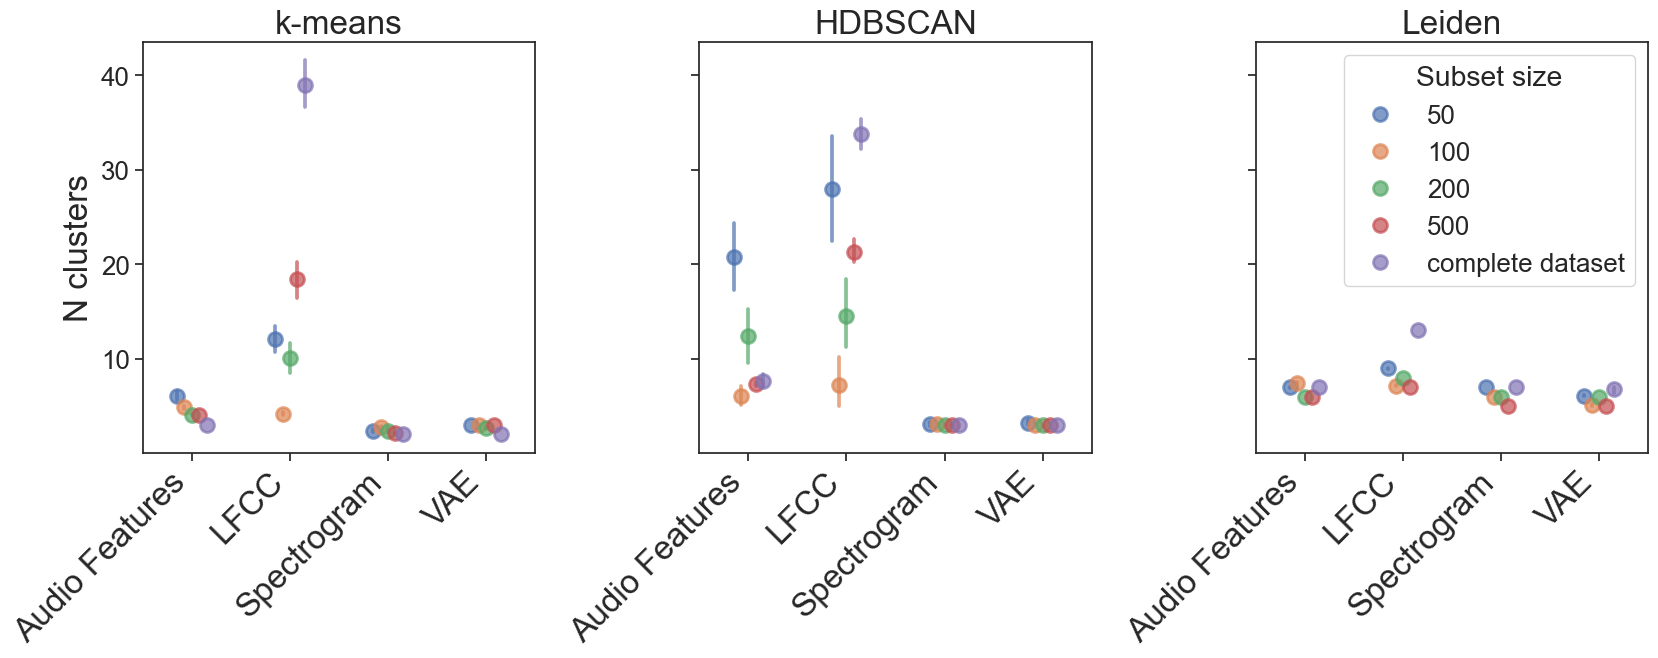

In [ ]:
rows = ["N clusters"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["Audio Features", "LFCC", "Spectrogram", "VAE"]

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(17, 7), sharex=True, sharey=True)
for row, metric in enumerate(rows):
    for col, representation in enumerate(columns):
        data = results_df[results_df["Algorithm"] == representation]

        sns.pointplot(
            x="Representation", 
            y=metric,  
            data=data, 
            ax=axs[col], 
            hue="Subset size", 
            linestyle="none",
            alpha=.7,
            errorbar="ci",
            dodge=.3,
            markersize=10,
            legend=(True if row==0 and col==2 else False)
        )
        # annotator = Annotator(axs[row, col], data=data, x="Representation", y=metric, pairs=pairs)
        # annotator.configure(test='t-test_paired', text_format='star', loc='outside')
        # annotator.apply_and_annotate()

        if row == 0:
            axs[col].set_title(representation, fontsize=24)

        #axs[row, col].set_ylim(0.1, 0.7)
        axs[col].set_xticklabels(representations, rotation=45, ha='right', fontsize=24)
        axs[col].set_xlabel("")

        if col == 0:
            axs[col].set_ylabel(metric, fontsize=24)  # Label only the first column
        else:
            axs[col].set_ylabel('')

plt.tight_layout()
plt.show()

/var/folders/kl/qgqbw3bd42bf_tybhvnz9vxh0000gn/T/ipykernel_73571/2616662050.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[col].set_xticklabels(['PAF', 'LFCC', 'Spectrograms', 'VAE representations'], rotation=45, ha='right')
/var/folders/kl/qgqbw3bd42bf_tybhvnz9vxh0000gn/T/ipykernel_73571/2616662050.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[col].set_xticklabels(['PAF', 'LFCC', 'Spectrograms', 'VAE representations'], rotation=45, ha='right')
/var/folders/kl/qgqbw3bd42bf_tybhvnz9vxh0000gn/T/ipykernel_73571/2616662050.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[col].set_xticklabels(['PAF', 'LFCC', 'Spectrograms', 'VAE representations'], rotation=45, ha='right')


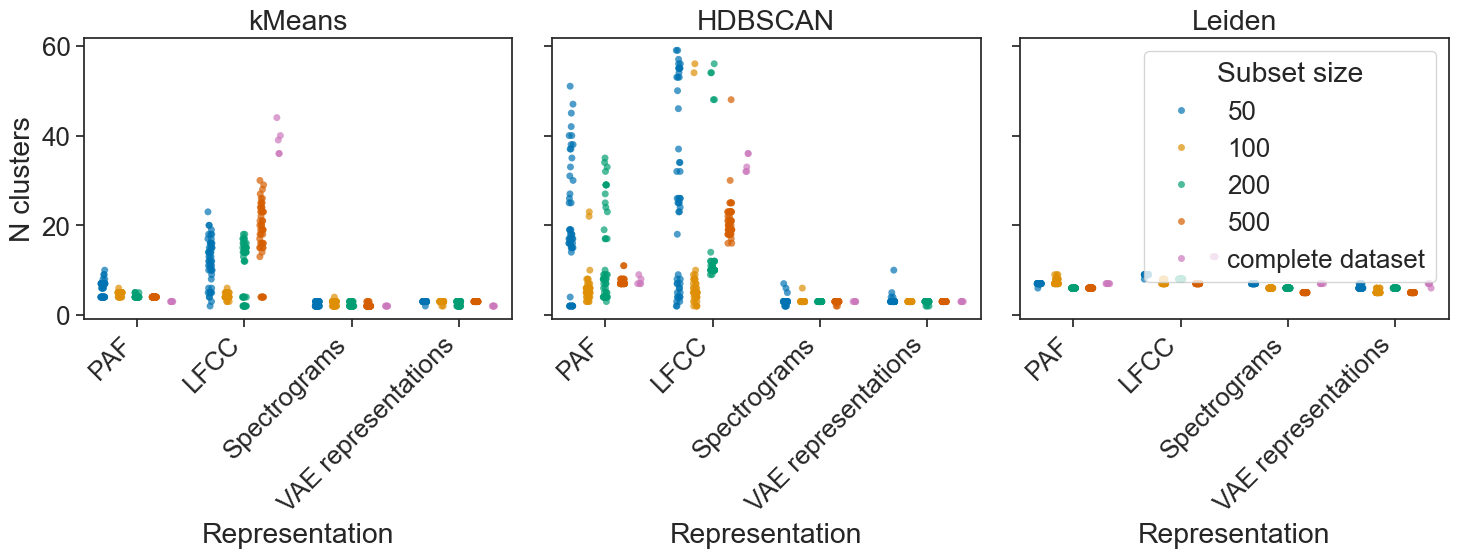

In [ ]:
rows = ["N clusters"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["PAF", "lfcc", "Spectrogram", "VAE"]


fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 6), sharex=True, sharey=True)
for row, metric in enumerate(rows):
    for col, representation in enumerate(columns):
        data = results_df[results_df["Algorithm"] == representation]

        # sns.boxplot(
        #     x="Representation", 
        #     y=metric,  
        #     data=data, 
        #     ax=axs[col], 
        #     hue="Subset size", 
        #     palette="colorblind",
        #     legend=(True if row==0 and col==2 else False)
        # )
        sns.stripplot(
            x="Representation", 
            y=metric,  
            data=data, 
            ax=axs[col], 
            hue="Subset size", 
            alpha=.7,
            dodge=.3,
            palette="light",
            legend=(True if row==0 and col==2 else False)
        )
        # sns.pointplot(
        #     x="Representation", 
        #     y=metric,  
        #     data=data, 
        #     ax=axs[col], 
        #     hue="Subset size", 
        #     linestyle="none",
        #     alpha=.7,
        #     errorbar="ci",
        #     dodge=.3,
        #     palette="colorblind",
        #     legend=(True if row==0 and col==2 else False)
        # )

        if row == 0:
            axs[col].set_title(representation)

        axs[col].set_xticklabels(['PAF', 'LFCC', 'Spectrograms', 'VAE representations'], rotation=45, ha='right')
        axs[col].set_ylabel("n groups")

        if col == 0:
            axs[col].set_ylabel(metric)  # Label only the first column
        else:
            axs[col].set_ylabel('')

plt.tight_layout()
plt.show()

/var/folders/kl/qgqbw3bd42bf_tybhvnz9vxh0000gn/T/ipykernel_20303/3339130981.py:8: UserWarning: The palette list has more values (9) than needed (3), which may not be intended.
  sns.boxplot(


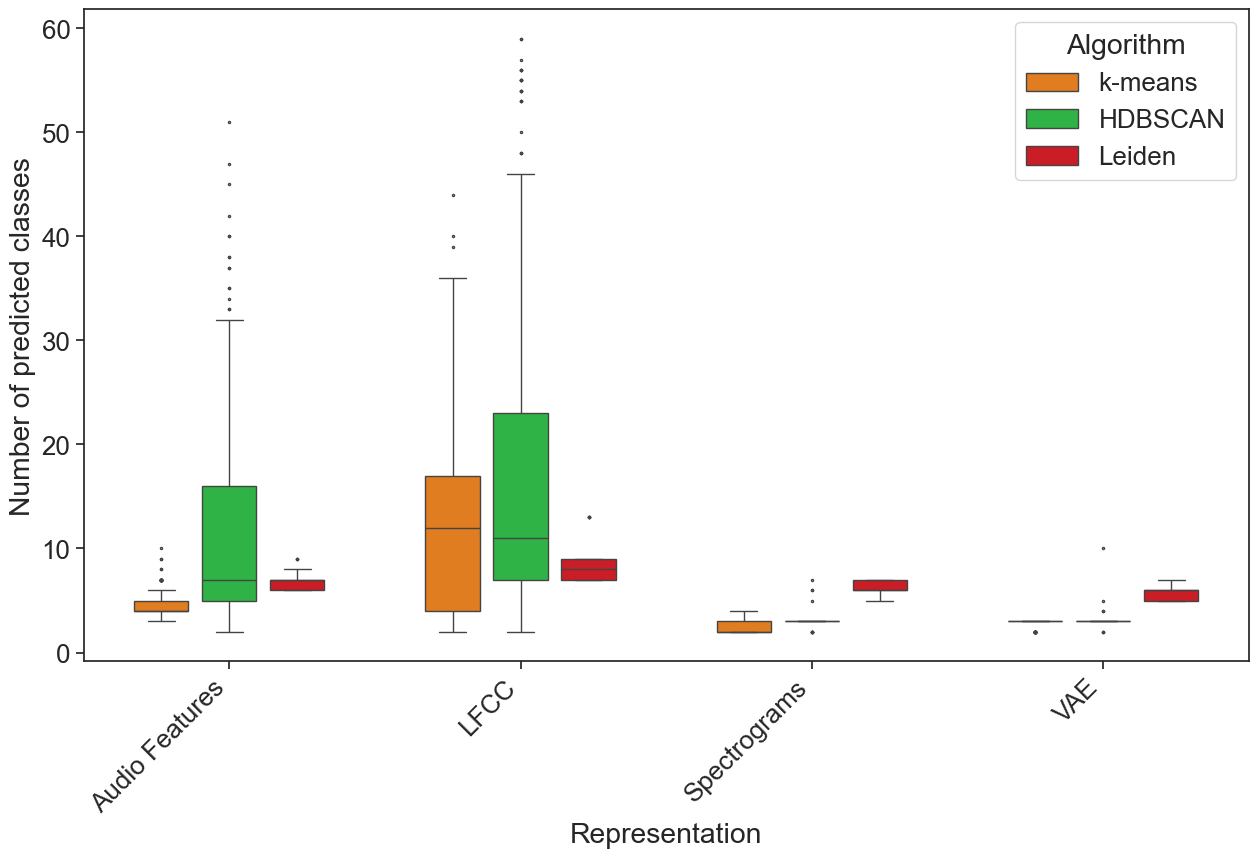

In [ ]:
rows = ["N clusters"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["PAF", "lfcc", "Spectrogram", "VAE"]
custom_palette = sns.color_palette("bright")[1:]

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(13, 9), sharex=True, sharey=True)

sns.boxplot(
    x="Representation", 
    y="N clusters",  
    data=results_df[results_df["Algorithm"]!="k-means-preset"], 
    ax=axs, 
    hue="Algorithm",
    legend=True, 
    gap=.2,
    width=.7,
    fliersize=1.5,
    palette=custom_palette
)

axs.set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE'])))
axs.set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE'], rotation=45, ha='right')
axs.set_ylabel("Number of predicted classes")
        
plt.tight_layout()
plt.show()

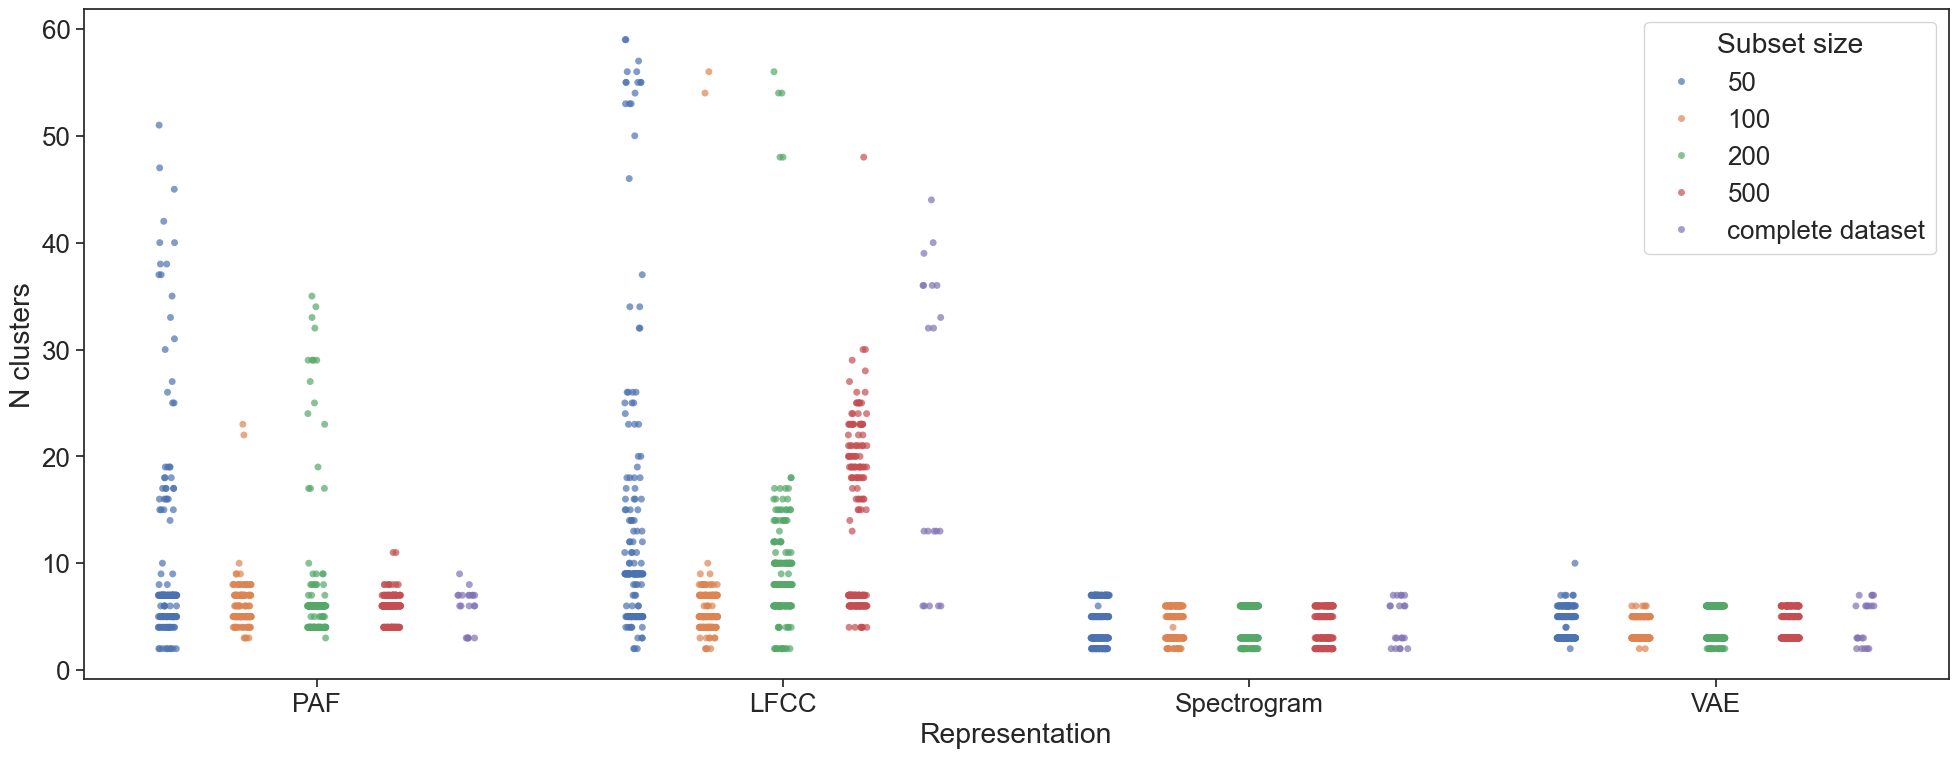

In [ ]:
rows = ["N clusters"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["PAF", "lfcc", "Spectrogram", "VAE"]

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(20, 8), sharex=True, sharey=True)

sns.stripplot(
    x="Representation", 
    y="N clusters",  
    data=results_df, 
    ax=axs, 
    hue="Subset size",
    alpha=.7,
    dodge=.3,
    legend=True
)
plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

results_without_preset = results_df.copy()[~(results_df["Algorithm"].isin(["k-means-preset", "Leiden-preset"]))]

results_without_preset.rename(columns={'Subset size': 'Subset_size', 'V-measure': 'V_measure', 'Adj. RS': 'Adj_RS', 'Distance metric': 'distance_metric'}, inplace=True)

formula = "V_measure ~ C(Representation) + C(Algorithm) + Subset_size"
glm_beta = smf.glm(formula, data=results_without_preset,
                    family=sm.families.Binomial(link=sm.families.links.logit())).fit()
# glm_beta = sm.GLM(y, X, family=sm.families.Binomial(link=sm.families.links.logit())).fit()
print(glm_beta.summary())

formula = "Adj_RS ~ C(Representation) + C(Algorithm) + Subset_size"
glm_beta = smf.glm(formula, data=results_without_preset,
                    family=sm.families.Binomial(link=sm.families.links.logit())).fit()
# glm_beta = sm.GLM(y, X, family=sm.families.Binomial(link=sm.families.links.logit())).fit()
print(glm_beta.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              V_measure   No. Observations:                 2460
Model:                            GLM   Df Residuals:                     2450
Model Family:                Binomial   Df Model:                            9
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1103.7
Date:                Thu, 27 Mar 2025   Deviance:                       26.331
Time:                        00:04:33   Pearson chi2:                     26.1
No. Iterations:                     3   Pseudo R-squ. (CS):            0.01974
Covariance Type:            nonrobust                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

/Users/lenagies/anaconda3/envs/goose_vocalizations/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The logit link alias is deprecated. Use Logit instead. The logit link alias will be removed after the 0.15.0 release.
  warnings.warn(
/Users/lenagies/anaconda3/envs/goose_vocalizations/lib/python3.11/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The logit link alias is deprecated. Use Logit instead. The logit link alias will be removed after the 0.15.0 release.
  warnings.warn(
